# UPRM Hackathon 2026 - Object Detection using Convolutional Neural Networks

**Author:** Hamzah Abdulrazzaq, Chelsea Cantone, Erika Hall, Edgar Perez

**Date:** September 25-27, 2026

**Objective:** UPRM Hackathon 2026 will be focused on exploring the capabilities of Convolutional Neural Networks (CNNs) in tackling complex object detection tasks. Specifically, participants will delve into the realm of single-class object detection using the 'Remondis Contamination Dataset' (RCD), which comprises truck-mounted waste camera imagery captured in real-world waste management operations. The dataset includes KITTI-format annotated images featuring plastic_bag instances of varying sizes, occlusion levels, lighting conditions, and background clutter, with bounding-box labels marking each target object. The task at hand is to design and optimize CNN-based detection architectures to accurately localize and classify plastic bags within a given image. The challenge lies in developing a robust model that can effectively handle the complexities of bounding-box regression combined with classification, requiring meticulous attention to data preprocessing, hyper-parameter tuning, and potentially incorporating techniques such as transfer learning, data augmentation, anchor tuning, and ensemble methods. The winning submissions will be evaluated based on their performance, with a key metric being the model's ability to achieve high mean Average Precision at IoU 0.50 (mAP@50) on the validation split, balancing precision and recall across detected instances.

## Table of Contents
1. [Background Information](#1-background-information)
    - [1.1. Convolutional Neural Networks](#11-convolutional-neural-networks)
    - [1.2. Object Detection vs Image Classification (Multi-label)](#12-object-detection-vs-image-classification-multi-label)
    - [1.3 An Example Use Case of Object Detection for Lockheed Martin](#13-an-example-use-case-of-object-detection-for-lockheed-martin)
    - [1.4 Key Terms](#14-key-terms)
    - [1.5 Helpful Resources](#15-helpful-resources)
2. [Setup](#2-setup)
    - [2.1. Download Data](#21-download-data)
    - [2.2 Importing Necessary Libraries](#22-importing-necessary-libraries)
    - [2.3 Custom Image Dataset](#23-custom-image-dataset)
    - [2.4 Image Augmentation](#24-image-augmentation)
3. [Training Loop](#3-training-loop)
    - [3.1 CNN Model Architecture](#31-cnn-model-architecture)
    - [3.2 Model Training](#32-model-training)
4. [Analysis](#4-analysis)
    - [4.1 Visualize Ground Truth vs Predictions](#41-visualize-ground-truth-vs-predictions)
    - [4.2 Performance Analysis (Where is the model underperforming)](#43-performance-analysis-where-is-the-model-underperforming)
5. [Test](#5-test)
    - [5.1 Download Test Data](#51-download-test-data)
    - [5.2 Create Test DataLoader](#51-create-test-dataloader)
    - [5.3 Grade Model on Test Set](#52-grade-model-on-test-set)
6. [Grading/Submission Guidelines](#6-gradingsubmission-guidelines)

## 1. Background Information

### 1.1 Convolutional Neural Networks:

A convolutional neural network (CNN or ConvNet) is a class of deep neural networks, most commonly applied to analyzing visual imagery. They have proven to be very effective in image and video recognition, recommender systems, image classification, medical image analysis, natural language processing, brain-computer interfaces, and financial time series modeling. CNNs are regularized versions of multilayer perceptrons. Multilayer perceptrons usually mean fully connected networks, that is, each neuron in one layer is connected to all neurons in the next layer. The "fully-connectedness" of these networks makes them prone to overfitting data. Typical ways of regularization include adding some form of magnitude measurement of weights to the loss function. CNNs take a different approach towards regularization: they take advantage of the hierarchical pattern in data and assemble more complex patterns using smaller and simpler patterns. Therefore, on the scale of connectedness and complexity, CNNs are on the lower extreme. Convolutional networks were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex. Individual cortical neurons respond to stimuli only in a restricted region of the visual field known as the receptive field. The receptive fields of different neurons partially overlap such that they cover the entire visual field.

### 1.2 Object Detection vs Image Classification (Multi-label)

![choose_computer_vision_arch.png](./img/choose_computer_vision_arch.png)

*[Image Source](https://storage.ghost.io/c/2c/8d/2c8d8c0d-1c15-4b6d-825e-02b78d61d40a/content/images/size/w1000/size/w2000/2020/07/choose_computer_vision_arch.png)*

Object detection vs image classification are two related but different challenges in computer vision. Object detection looks at digital images and videos to locate objects of interest and label them.

| Image Classification (multi-label) | Object Detection |
| :--- | :--- |
| *Questions*: What labels are present in this image? | *Questions*: Is there an object here (objectness)? Where are the objects in the image (localization)? What labels are present (classification)? |
| *Output*: Class probabilities | *Output*: Bounding boxes, class probabilities, confidence scores (objectness) |
| *Evaluation metric*: F1-score | *Evaluation metric*: mAP@50 IoU, mean average precision at 50% Intersection over Union |

For explanation of mAP, see the references section below. mAP@50 indicates the mean Average Precision, where the Intersection over Union threshold is set to 0.5. Practically this means that the overlap of the ground truth bounding box to the predicted bounding box sufficiently overlap.

![Intersection over Union](./img/IoU-graphic.png)

[*Source*](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FrmKLxCtkokDC3Yr1wc70w.png)

### 1.3 An Example Use Case of Object Detection for Lockheed Martin
> GATR (Globally-scalable Automated Target Recognition) is a Lockheed Martin software system for real-time object detection and classification in satellite imagery on a worldwide basis. 
![GATR Object Detection](./img/Screenshot%202026-08-10%20134544.png)

[*Globally-scalable Automated Target Recognition (GATR) 2019*](https://arxiv.org/pdf/2009.04836)

### 1.4 Key Terms:
- **Anchor box** - in some object detection CNN models predefined reference boxes, of fixed size and aspect ratio, are used to localize objects
- **Backbone** - a backbone is a very unspecialized CNN that is inserted into a computer vision model to extract essential visual features from raw images (edges, corners, textures, shapes, etc.) into a feature map. Example backbone are ResNet, CSPNet, or a Vision Transformer.
- **Bounding box (bbox)** - the rectangular frame surrounding an object in an image or video. Our labeled dataset contains ground truth bounding boxes that were annotated by humans. We will compare the bounding boxes generated by our model to the ground truth annotations.
- **Localization** - uses regression to predict four numbers representing bounding box coordinates (center point, width, and height).
- **Objectness** - in computer vision, measure that scores how likely a specific image window contains an actual object rather than background.
- **Non-Maximum Suppression (NMS)** - A post processing technique to remove overlapping bounding boxes of the same objecct. Some computer vision models do not deal with this challenge.


### 1.5 Helpful Resources:

Neural Networks:
- [What are Convolutional Neural Networks](https://www.bing.com/videos/search?q=convolutional+neural+network&docid=603549927117705930&mid=E7ED04059A9474B24BFEE7ED04059A9474B24BFE&view=detail&FORM=VIRE)
- [CNN Explainer - Learn CNN In Your Browser](https://poloclub.github.io/cnn-explainer/)
- [Neural Network Playground](https://playground.tensorflow.org/)
- [Interactive Demo for Image kernels](https://deeplizard.com/resource/pavq7noze2)
- [Introduction to Pooling Layers](https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/)

Object Detection
- [Overview of Object Detection](https://machinelearningmastery.com/object-recognition-with-deep-learning/)
- [Anchor-Based vs Anchor-Free Object Detection](https://www.abhik.ai/concepts/computer-vision/anchor-based-vs-anchor-free)
- [YOLO Object Detection Explained](https://www.datacamp.com/blog/yolo-object-detection-explained)
- [mAP (mean Average Precision) for Object Detection](https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173)

## 2. Setup

### 2.1. Download Data

The data lives in the repository's `data/` folder, so the structure looks like:

```
data/
  training/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
  val/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
```

### 2.2 Importing Necessary Libraries

In [1]:
# Installs into the kernel running this notebook (a no-op when scripts/aws_setup.sh already set it up).
# requirements.txt is the organizers' file next to this notebook; the YOLO26 package is pinned explicitly.
import subprocess
import sys
from pathlib import Path

_reqs = ["-r", "requirements.txt"] if Path("requirements.txt").exists() else []
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_reqs, "ultralytics==8.4.163"])

0

In [2]:
import math
import os
import random
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import boxes as box_ops
import torchvision.transforms.functional as TF
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Repository root (assumes the notebook lives in <repo>/event_materials/).
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "event_materials" else Path.cwd()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class id 0 is reserved for background in torchvision detection models.
CLASS_NAME_TO_ID = {"plastic_bag": 1}
NUM_CLASSES = 1 + len(CLASS_NAME_TO_ID)  # background + foreground

print(f"Using device: {DEVICE}")
print(f"NUM_CLASSES (background + foreground): {NUM_CLASSES}")
print(f"Repo root: {REPO_ROOT}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected.")


# ---------------------------------------------------------------------------
# YOLO26x at 640 px (same recipe as the YOLO26m comparison). EVERY experiment setting is in this block.
#   "full"     - train MODEL_WEIGHTS from its COCO-pretrained weights, then score EVERY saved checkpoint.
#   "evaluate" - no training and no data conversion: score EVAL_CHECKPOINT at EVAL_IMGSZ.
# ---------------------------------------------------------------------------
RUN_MODE = "full"
EXPERIMENT = "X"               # label used in run names, plots and the comparison (YOLO26x)
MODEL_WEIGHTS = "yolo26x.pt"   # COCO-pretrained starting point (downloaded on first use)
TRAIN_IMGSZ = 640
EVAL_IMGSZ = TRAIN_IMGSZ       # first evaluation at the training resolution; the ONLY evaluation size used below
TRAIN_BATCH = 4                # out of GPU memory: rerun at 2, then 1, under a NEW run name (never a silent change)
EPOCHS = 100
RUN_NAME = None                # None = "<mode>_cmp<EXPERIMENT>_<model>_train<T>_eval<E>_b<batch>_ep<epochs>_<timestamp>"
EVAL_CHECKPOINT = None         # evaluate mode: a trained .pt, e.g. REPO_ROOT / "runs" / "detect" / "<run>" / "weights" / "last.pt"
RESUME_FROM = None             # continue an interrupted full run: path to its runs/detect/<run>/weights/last.pt

if RUN_MODE not in ("full", "evaluate"):
    raise ValueError(f"RUN_MODE must be 'full' or 'evaluate', got {RUN_MODE!r}")
if RUN_MODE == "evaluate":
    if EVAL_CHECKPOINT is None:
        raise ValueError("RUN_MODE = 'evaluate' needs EVAL_CHECKPOINT set to a trained .pt file")
    if not Path(EVAL_CHECKPOINT).is_file():
        raise FileNotFoundError(f"EVAL_CHECKPOINT not found: {EVAL_CHECKPOINT}")
MODE_CFG = {
    "full": dict(epochs=EPOCHS, batch=TRAIN_BATCH, fraction=1.0, close_mosaic=15, save_period=5),
    "evaluate": dict(epochs=0, batch=TRAIN_BATCH, fraction=1.0, close_mosaic=0, save_period=-1),
}
CFG = dict(MODE_CFG[RUN_MODE])

# Competition scoring settings: low confidence so the metric sees the whole precision-recall curve.
EVAL_KW = dict(imgsz=EVAL_IMGSZ, conf=0.001, iou=0.7, max_det=300, augment=False)
DEVICE_ARG = "0" if torch.cuda.is_available() else "cpu"   # Ultralytics device string

import time
if RUN_NAME is None:
    RUN_NAME = (f"{RUN_MODE}_cmp{EXPERIMENT}_{Path(MODEL_WEIGHTS).stem}_train{TRAIN_IMGSZ}_eval{EVAL_IMGSZ}"
                f"_b{TRAIN_BATCH}_ep{EPOCHS}_{time.strftime('%Y%m%d_%H%M%S')}")
print(f"RUN_MODE = {RUN_MODE!r}   EXPERIMENT = {EXPERIMENT!r}   RUN_NAME = {RUN_NAME!r}")
print(f"model {MODEL_WEIGHTS} | train imgsz {TRAIN_IMGSZ} | eval imgsz {EVAL_IMGSZ} | batch {TRAIN_BATCH} | "
      f"epochs {EPOCHS}")

Using device: cuda
NUM_CLASSES (background + foreground): 2
Repo root: /home/sagemaker-user/uprm-hackathon-2026
NVIDIA A10G
RUN_MODE = 'full'   EXPERIMENT = 'X'   RUN_NAME = 'full_cmpX_yolo26x_train640_eval640_b4_ep100_20260926_214457'
model yolo26x.pt | train imgsz 640 | eval imgsz 640 | batch 4 | epochs 100


In [3]:
if torch.cuda.is_available():
    # Returns bytes; convert to MB
    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    
    print(f"Allocated by PyTorch Tensors: {allocated:.2f} MB")
    print(f"Cached/Reserved by PyTorch:    {reserved:.2f} MB")
    
    # Or print a highly detailed diagnostic summary
    print(torch.cuda.memory_summary(device=0))

if RUN_MODE == "full" and not torch.cuda.is_available():
    raise RuntimeError("Training needs a CUDA GPU - use a GPU instance/kernel (e.g. ml.g5.xlarge).")

Allocated by PyTorch Tensors: 0.00 MB
Cached/Reserved by PyTorch:    0.00 MB
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   | 

In [4]:
import warnings 
warnings.filterwarnings("ignore")

### 2.3 Custom Image Dataset

A PyTorch Custom Image Dataset is a class that inherits from PyTorch's Dataset class which provides a way to create a dataset that is tailored to your requirements and needs. It integrates efficiently with PyTorch's DataLoader, allowing us to load and process images in batches during model training and validation

#### What is it used for?
- Data Loading: Standardized way to load images and labels from disk.
- Data Preprocessing: Consistent application of transformations (resizing, augmentation, etc.) to images.
- Batch Creation: Mini-batch generation for training.
- Memory Efficiency: Load images only when needed rather than storing entire dataset in memory. 

Provided below is a custom image dataset that you may use for this challenge. You may add your own modifications by reading through [PyTorch's documentation](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html). 

In [5]:
# Directory names differ between the two splits (hard-coded on disk).
_SPLIT_DIRS = {
    "train": ("image", "label"),
    "val":   ("image",   "label"),
    "test": ("image", "label")
}


def _parse_kitti_label(label_path: Path) -> Tuple[List[List[float]], List[int]]:
    """Parse a single KITTI-format .txt file into boxes and labels.

    Returns (boxes_xyxy, labels). Boxes with non-positive width/height are dropped.
    Only foreground classes in CLASS_NAME_TO_ID are kept; others are silently ignored.
    """
    boxes: List[List[float]] = []
    labels: List[int] = []
    if not label_path.exists():
        return boxes, labels
    with open(label_path, "r") as f:
        for raw in f:
            parts = raw.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in CLASS_NAME_TO_ID:
                continue
            xmin, ymin, xmax, ymax = (float(parts[4]), float(parts[5]),
                                      float(parts[6]), float(parts[7]))
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_NAME_TO_ID[cls])
    return boxes, labels


class KittiPlasticBagDataset(Dataset):
    """PyTorch Dataset over KITTI-format plastic-bag data (self-contained version)."""

    def __init__(
        self,
        root,
        split: str = "train",
        transforms: Optional[Callable] = None,
    ) -> None:
        if split not in _SPLIT_DIRS:
            raise ValueError(f"split must be one of {list(_SPLIT_DIRS)}, got {split!r}")
        self.split = split
        self.transforms = transforms

        root = Path(root)
        # Accept either the repo `data/` folder or a specific split root.
        if (root / "training").is_dir() and (root / "val").is_dir():
            split_root = root / ("training" if split == "train" else split)
        else:
            split_root = root
        img_dir_name, lbl_dir_name = _SPLIT_DIRS[split]
        self.image_dir = split_root / img_dir_name
        self.label_dir = split_root / lbl_dir_name
        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image dir not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label dir not found: {self.label_dir}")

        stems = sorted(p.stem for p in self.image_dir.glob("*.jpg"))
        self.ids: List[str] = [s for s in stems if (self.label_dir / f"{s}.txt").exists()]
        if not self.ids:
            raise RuntimeError(f"No paired image/label files found under {split_root}")

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]
        img_path = self.image_dir / f"{stem}.jpg"
        lbl_path = self.label_dir / f"{stem}.txt"

        img = Image.open(img_path).convert("RGB")
        boxes, labels = _parse_kitti_label(lbl_path)

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)

        return img, target


def detection_collate_fn(batch):
    """Detection targets are variable-length; keep them as a tuple of dicts."""
    images, targets = list(zip(*batch))
    return list(images), list(targets)


### 2.4 Image Augmentation

Image augmentation is an absolutely wonderful way to artificially expand your training dataset, which is especially valuable when working with limited data — a common constraint in real-world image tasks. By creating variations of existing images through transformations like rotations, flips, zooms, and crops, you essentially teach your CNN to recognize objects under different viewing conditions without collecting additional data.

More fundamentally, augmentation directly addresses overfitting by preventing the network from memorizing exact pixel patterns. When a CNN sees the same exact images repeatedly, it tends to learn specific pixel configurations rather than generalizable features. By presenting slightly different versions each time, you force the network to learn robust representations that capture the essence of objects rather than superficial details.

Augmentation also introduces invariance properties into your model. For classification tasks, whether an image is slightly rotated, zoomed, or shifted shouldn't change the label. By training with these variations, your CNN develops translation, rotation, and scale invariance—crucial properties for real-world deployment where objects rarely appear in perfectly consistent positions or orientations.

The CustomImageDataset created above is setup to handle image transforms. An example is provided below with horizontal flip and color jitter transforms applied. See documentation [here](https://docs.pytorch.org/vision/stable/transforms.html?highlight=compose)

In this corrected notebook YOLO26 applies its own on-the-fly augmentation during training (mosaic, horizontal flip 0.5, scale 0.5; no mixup, vertical flips or rotation), configured as `AUGMENT` in the cell below. The `TrainTransforms` example is kept for reference but is not used by YOLO training.

In [6]:
from torchvision.transforms import ColorJitter


class TrainTransforms:
    """Light on-the-fly augmentation for the training split.

    - Random horizontal flip (with box coord update).
    - Photometric color jitter (brightness/contrast/saturation/hue) applied
      to the PIL image before tensor conversion. Reduces train/val
      overconfidence gap without needing to re-map bounding boxes.
    - PIL -> float tensor in [0, 1], CHW.
    """

    def __init__(self, hflip_prob: float = 0.5) -> None:
        self.hflip_prob = float(hflip_prob)
        self.color_jitter = ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05,
        )

    def __call__(self, img: Image.Image, target: dict) -> Tuple[torch.Tensor, dict]:
        if self.hflip_prob > 0 and random.random() < self.hflip_prob:
            w = img.width
            img = TF.hflip(img)
            if target["boxes"].numel() > 0:
                boxes = target["boxes"].clone()
                x1 = w - boxes[:, 2]
                x2 = w - boxes[:, 0]
                boxes[:, 0] = x1
                boxes[:, 2] = x2
                target["boxes"] = boxes

        # Photometric jitter operates purely on pixel intensities; boxes
        # are unchanged, so no target update is needed here.
        img = self.color_jitter(img)

        img_t = TF.to_tensor(img)
        return img_t, target


# Augmentation actually used by YOLO26 training (passed to Ultralytics in section 3.2)
AUGMENT = dict(mosaic=1.0, fliplr=0.5, scale=0.5, mixup=0.0, flipud=0.0, degrees=0.0)
print("YOLO augmentation:", AUGMENT)

YOLO augmentation: {'mosaic': 1.0, 'fliplr': 0.5, 'scale': 0.5, 'mixup': 0.0, 'flipud': 0.0, 'degrees': 0.0}


### 2.6 Datasets and DataLoader

In [7]:
DATA_ROOT = REPO_ROOT / "data"
print("Data root:", DATA_ROOT)

# The organizers' Dataset is used for scoring; YOLO trains from a converted copy of the training split (below).
val_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="val")
print(f"val   samples: {len(val_ds)}")

# Evaluation batch size (training batch size comes from RUN_MODE)
BATCH_SIZE = 8
# NUM_WORKERS = 0 is the safe choice on SageMaker (small shared memory)
NUM_WORKERS = 0

# Exactly the starter notebook's val_loader (drop_last=True) ...
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=True
)
# ... and one that scores every validation image (used to select checkpoints)
val_loader_full = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

# --- KITTI -> YOLO label conversion (training modes only) ---
# Boxes are normalized by each image's own size (the data mixes 1280x720, 640x480 and 480x320).
CLASS_NAMES = ["plastic_bag"]
YOLO_DATA_ROOT = REPO_ROOT / "yolo_data"

"""Convert the organizers' KITTI splits into an Ultralytics YOLO dataset (yolo_data/)."""

import argparse
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import yaml
from PIL import Image


EXIF_ORIENTATION = 0x0112


@dataclass
class ConvertStats:
    images: int = 0
    boxes: int = 0
    dropped: int = 0


def kitti_line_to_yolo(line: str, img_w: int, img_h: int) -> Optional[str]:
    """One KITTI row -> 'cls cx cy w h' normalized to [0, 1], or None if the row is unusable."""
    parts = line.strip().split()
    if len(parts) < 8 or parts[0] not in CLASS_NAMES:
        return None
    x1, y1, x2, y2 = (float(v) for v in parts[4:8])
    x1, y1 = max(0.0, x1), max(0.0, y1)
    x2, y2 = min(float(img_w), x2), min(float(img_h), y2)
    if x2 <= x1 or y2 <= y1:
        return None
    cls_id = CLASS_NAMES.index(parts[0])
    cx = (x1 + x2) / 2.0 / img_w
    cy = (y1 + y2) / 2.0 / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    return f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


def convert_split(src_split_dir: Path, dst_root: Path, split: str, clean: bool = True) -> ConvertStats:
    """Copy <src>/image/*.jpg and write YOLO labels into <dst>/images/<split>, <dst>/labels/<split>."""
    src_split_dir, dst_root = Path(src_split_dir), Path(dst_root)
    img_dst = dst_root / "images" / split
    lbl_dst = dst_root / "labels" / split
    for d in (img_dst, lbl_dst):
        if clean and d.exists():
            # empty the folder but keep it: Windows/OneDrive can refuse to remove the directory itself
            for child in d.iterdir():
                shutil.rmtree(child) if child.is_dir() else child.unlink()
        d.mkdir(parents=True, exist_ok=True)
    (dst_root / "labels" / f"{split}.cache").unlink(missing_ok=True)  # Ultralytics label cache

    stats = ConvertStats()
    for img_path in sorted((src_split_dir / "image").glob("*.jpg")):
        lbl_path = src_split_dir / "label" / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue  # the organizers' dataset also skips unpaired images
        if (img_dst / img_path.name).exists():
            raise FileExistsError(f"{img_dst / img_path.name} already exists; refusing to overwrite")
        with Image.open(img_path) as im:
            orientation = im.getexif().get(EXIF_ORIENTATION)
            if orientation not in (None, 1):
                raise ValueError(f"{img_path} has EXIF orientation {orientation}; labels would misalign")
            img_w, img_h = im.size
        rows = []
        for line in lbl_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            row = kitti_line_to_yolo(line, img_w, img_h)
            if row is None:
                stats.dropped += 1
            else:
                rows.append(row)
        shutil.copy2(img_path, img_dst / img_path.name)
        (lbl_dst / f"{img_path.stem}.txt").write_text("".join(r + "\n" for r in rows))
        stats.images += 1
        stats.boxes += len(rows)
    return stats


def write_dataset_yaml(dst_root: Path) -> Path:
    dst_root = Path(dst_root).resolve()
    cfg = {"path": str(dst_root), "train": "images/train", "val": "images/val",
           "names": {i: name for i, name in enumerate(CLASS_NAMES)}}
    out = dst_root / "data.yaml"
    out.write_text(yaml.safe_dump(cfg, sort_keys=False))
    return out


def build_yolo_dataset(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT, train_on_val: bool = False) -> Path:
    """Build the whole YOLO dataset; train_on_val=True also copies val images into train (final retrain only)."""
    data_root, dst_root = Path(data_root), Path(dst_root)
    jobs = [("training", "train", True), ("val", "val", True)]
    if train_on_val:
        jobs.append(("val", "train", False))
    for src_name, split, clean in jobs:
        s = convert_split(data_root / src_name, dst_root, split, clean=clean)
        print(f"{src_name} -> {split}: {s.images} images, {s.boxes} boxes, {s.dropped} dropped")
    return write_dataset_yaml(dst_root)


def _paired_images(split_dir: Path) -> list:
    return sorted(p.name for p in (split_dir / "image").glob("*.jpg") if (split_dir / "label" / f"{p.stem}.txt").exists())


def dataset_is_current(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT) -> bool:
    """True if dst_root already holds exactly the converted train/val images and labels of data_root."""
    data_root, dst_root = Path(data_root), Path(dst_root)
    for src_name, split in (("training", "train"), ("val", "val")):
        want = _paired_images(data_root / src_name)
        have = sorted(p.name for p in (dst_root / "images" / split).glob("*.jpg"))
        labels = sorted(p.stem for p in (dst_root / "labels" / split).glob("*.txt"))
        if not want or have != want or labels != [Path(n).stem for n in want]:
            return False
    return True


def ensure_yolo_dataset(data_root: Path = DATA_ROOT, dst_root: Path = YOLO_DATA_ROOT) -> Path:
    """Reuse an up-to-date conversion (only data.yaml is rewritten, with THIS machine's path); otherwise rebuild."""
    if dataset_is_current(data_root, dst_root):
        print(f"reusing converted dataset in {dst_root}")
        return write_dataset_yaml(dst_root)
    return build_yolo_dataset(data_root, dst_root)

if RUN_MODE == "evaluate":
    DATA_YAML = None
    print("evaluate mode: training-data conversion skipped")
else:
    DATA_YAML = ensure_yolo_dataset(DATA_ROOT, YOLO_DATA_ROOT)  # data.yaml always holds THIS machine's path

_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (no CUDA GPU)"
_model = str(EVAL_CHECKPOINT) if RUN_MODE == "evaluate" else MODEL_WEIGHTS
print("=" * 88)
print(f"mode: {RUN_MODE} | experiment: {EXPERIMENT} | GPU: {_gpu} | model: {_model}")
print(f"train imgsz: {TRAIN_IMGSZ} | eval imgsz: {EVAL_IMGSZ} | scoring settings: {EVAL_KW}")
print(f"epochs: {CFG['epochs']} | train batch: {CFG['batch']} | train fraction: {CFG['fraction']} | "
      f"evaluated val images: {len(val_ds)}")
print("=" * 88)

Data root: /home/sagemaker-user/uprm-hackathon-2026/data
val   samples: 199
reusing converted dataset in /home/sagemaker-user/uprm-hackathon-2026/yolo_data
mode: full | experiment: X | GPU: NVIDIA A10G | model: yolo26x.pt
train imgsz: 640 | eval imgsz: 640 | scoring settings: {'imgsz': 640, 'conf': 0.001, 'iou': 0.7, 'max_det': 300, 'augment': False}
epochs: 100 | train batch: 4 | train fraction: 1.0 | evaluated val images: 199


## 3. Training Loop

### 3.1 CNN Model Architecture

There are two ways to approaching the model architecture phase of the problem. 

1. Building your own CNN architecture. An example is provided below where modifications can be made. 
2. Using pretrained models.

#### Building Your Own CNN Architecture

__Advantages:__

- Complete control over the architecture design. 
- Freedom to experiment with novel layer arrangements, activation functions, and skip connections.
- No constraints from pretrained weights or architectures that may not be optimal for your domain.
- Typically results in a smaller, more compute efficient model since you only include what you need.

__Disadvantages:__

- Requires a bit more expertise and understanding of Neural Network design
- More epochs are needed as learning must start from random initialization
- Needs much more data to achieve good performance (often prohibitively large amounts)
- Higher risk of overfitting, especially with limited data

#### Using Pretrained Models

__Advantages:__

- Leverage powerful feature extractors trained on massive datasets (like ImageNet with 1.2M images)
- Dramatically reduced training time and computational requirements (though more compute resources are needed to get started)
- Excellent performance even with limited domain-specific data
- Built-in robustness against common image variations and noise
- Access to state-of-the-art architectures (ResNet, EfficientNet, Vision Transformers) without designing them

__Disadvantages:__

- Less control over the underlying architecture
- May include unnecessary complexity for simpler tasks
- Domain shift can be problematic if your images differ significantly from pretraining data
- Fixed input requirements (resolution, channels) that may require preprocessing

**This comparison notebook uses option 2:** a COCO-pretrained Ultralytics **YOLO26** CNN detector (`MODEL_WEIGHTS`, YOLO26x trained and scored at 640 px), fine-tuned on our data.

#### Object Detection CNN Model Building Blocks
Recall that we are only predicting a single class (plastic bags)
- CNN Backbone to extract feature map
- Detection Head to produce objectness score (detecting foreground vs background) and bounding box regression

**CNN Backbone**

YOLO26x uses a pretrained convolutional backbone and a feature-pyramid neck. It is the largest version, wider than YOLO26l with the same structure, and it produces feature maps at strides 8, 16 and 32, so both small and large plastic bags are covered. The cell below loads `MODEL_WEIGHTS` in `full` mode, or `EVAL_CHECKPOINT` in `evaluate` mode, and prints the parameter count.

In [8]:
from ultralytics import YOLO

if RUN_MODE == "evaluate":
    yolo = YOLO(str(EVAL_CHECKPOINT))
elif RESUME_FROM is not None:
    yolo = YOLO(str(RESUME_FROM))
else:
    _local = REPO_ROOT / "weights" / MODEL_WEIGHTS
    yolo = YOLO(str(_local) if _local.exists() else MODEL_WEIGHTS)  # downloads the COCO weights on first use

yolo.info()
print("classes in this checkpoint:", len(yolo.names), "(the head is re-initialized for plastic_bag when training)")

YOLO26x summary: 392 layers, 58,993,368 parameters, 0 gradients, 210.1 GFLOPs
classes in this checkpoint: 80 (the head is re-initialized for plastic_bag when training)


**Detection Head**

The YOLO26 head predicts boxes and a class score per location. Training uses `single_cls=True`, so the only class is `plastic_bag`.

- **Head choice:** YOLO26 can run an NMS-free end-to-end head. By default the installed Ultralytics uses the NMS head, and the cell below records which one actually runs.
- **Scoring settings:** `conf=0.001` (so the mAP sees the full precision-recall curve), `iou=0.7` NMS, and at most 300 detections per image.

In [9]:
"""Make an Ultralytics YOLO model look like the organizers' torchvision-style detector."""

from pathlib import Path
from typing import Any, Dict, List, Optional, Union

import numpy as np
import torch
import torch.nn as nn

NMS_CANDIDATES = ("nms", "end2end")


def resolve_nms_kwarg(cfg_keys=None) -> str:
    """The installed Ultralytics predict() argument that selects YOLO26's NMS head vs its NMS-free end-to-end head.

    Verified against the installed default config rather than guessed; fails loudly if neither name exists.
    """
    if cfg_keys is None:
        from ultralytics.cfg import DEFAULT_CFG_DICT
        cfg_keys = DEFAULT_CFG_DICT
    for key in NMS_CANDIDATES:
        if key in cfg_keys:
            return key
    raise RuntimeError(f"installed ultralytics exposes none of {NMS_CANDIDATES}; cannot select the YOLO26 head")


try:
    NMS_KWARG = resolve_nms_kwarg()
except ImportError:  # ultralytics not installed (pure unit-test environments)
    NMS_KWARG = "nms"


def tensor_to_bgr_uint8(img: torch.Tensor) -> np.ndarray:
    """[3,H,W] float RGB in [0,1] (TF.to_tensor output) -> [H,W,3] uint8 BGR (Ultralytics' numpy convention)."""
    arr = img.detach().to("cpu", torch.float32).clamp(0.0, 1.0).mul(255.0).round().to(torch.uint8)
    return np.ascontiguousarray(arr.permute(1, 2, 0).numpy()[:, :, ::-1])

**Full Detector (organizer-compatible adapter)**

`YoloTorchvisionAdapter` wraps YOLO so the organizers' unchanged `evaluate_map50` and `visualize_predictions` can use it.
- **Input:** a list of RGB float tensors `[3, H, W]` (the `KittiPlasticBagDataset` output). They are converted to what YOLO expects.
- **Output:** `[{"boxes", "scores", "labels"}]`. Boxes are `xyxy` in **original-image pixels** and labels are always `1` (plastic_bag).
- **Safe `.eval()`:** the YOLO object is deliberately not a registered submodule, so `.eval()` can never start YOLO training.

In [10]:
class YoloTorchvisionAdapter(nn.Module):
    """forward(List[Tensor[3,H,W]]) -> List[{"boxes","scores","labels"}] in original-image pixel coords.

    Drop-in for the starter notebook's `evaluate_map50(model, loader, device)` and `visualize_predictions(...)`.
    """

    def __init__(
        self,
        weights: Union[str, Path, Any],
        imgsz: int = 640,
        conf: float = 0.001,
        iou: float = 0.7,
        max_det: int = 300,
        augment: bool = False,
        nms: Optional[bool] = None,
        device: Optional[str] = None,
    ) -> None:
        super().__init__()
        if isinstance(weights, (str, Path)):
            from ultralytics import YOLO
            weights = YOLO(str(weights))
        # Deliberately NOT a registered submodule: ultralytics' Model.train() is the training
        # entrypoint, so nn.Module.eval() recursing into it would launch a training run.
        object.__setattr__(self, "_yolo", weights)
        self.predict_kwargs: Dict[str, Any] = dict(
            imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, augment=augment, verbose=False)
        if nms is not None:
            self.predict_kwargs[NMS_KWARG] = nms
        if device is not None:
            self.predict_kwargs["device"] = device

    def train(self, mode: bool = True) -> "YoloTorchvisionAdapter":
        self.training = mode  # inference-only wrapper; never recurse into the YOLO object
        return self

    def inference_mode(self) -> Dict[str, Any]:
        """What actually ran: the NMS kwarg/value we passed and the head the loaded predictor ended up using."""
        predictor = getattr(self._yolo, "predictor", None)
        backend = getattr(predictor, "model", None)
        return {"nms_kwarg": NMS_KWARG, "nms_value": self.predict_kwargs.get(NMS_KWARG),
                "end2end_head": getattr(backend, "end2end", None),
                **{k: v for k, v in self.predict_kwargs.items() if k != "verbose"}}

    @torch.no_grad()
    def forward(self, images: List[torch.Tensor], targets: Optional[list] = None) -> List[Dict[str, torch.Tensor]]:
        if not images:
            return []
        results = self._yolo.predict([tensor_to_bgr_uint8(img) for img in images], **self.predict_kwargs)
        outputs = []
        for res in results:
            xyxy = res.boxes.xyxy.detach().cpu().float().reshape(-1, 4)
            scores = res.boxes.conf.detach().cpu().float().reshape(-1)
            outputs.append({"boxes": xyxy, "scores": scores,
                            "labels": torch.ones(scores.numel(), dtype=torch.int64)})
        return outputs


# Sanity check: .eval() can never reach YOLO.train()
_check = YoloTorchvisionAdapter(yolo, device=DEVICE_ARG, **EVAL_KW)
assert _check.eval() is _check and list(_check.children()) == []
print("adapter OK | NMS-mode argument in this Ultralytics:", NMS_KWARG)

adapter OK | NMS-mode argument in this Ultralytics: nms


### 3.2 Model Training

Ultralytics training from the **COCO-pretrained** `MODEL_WEIGHTS`. The model, training image size, evaluation image size, batch size, epochs and run name all come from the one configuration block in section 2.2.

The fixed settings are:
- early stopping off (`patience=0`) and no frozen layers
- cosine learning-rate schedule
- mixed precision
- `optimizer="auto"` (the resolved choice is recorded)
- seed 42 and `deterministic=True`
- mosaic turned off for the final 15 epochs
- a checkpoint every 5 epochs, plus `best.pt` and `last.pt`

The run configuration and environment are written to the run folder **before** training starts. If the requested batch does not fit in GPU memory, training stops and the failure is written to `rcd_failed.json`. Otherwise Ultralytics would quietly halve the batch and the comparison would no longer be matched.

In [11]:
# Run configuration + environment metadata (written before training starts)
PROJECT_ROOT = REPO_ROOT
"""Capture the software/hardware environment of a run (written before training starts)."""

import json
import platform
import socket
import subprocess
import sys
from datetime import datetime
from pathlib import Path
from typing import Any, Dict



def code_version(root: Path = PROJECT_ROOT) -> Dict[str, Any]:
    """Git SHA (+dirty flag) when run from a checkout, else the packaged manifest's code-tree hash."""
    try:
        sha = subprocess.run(["git", "rev-parse", "HEAD"], cwd=root, capture_output=True, text=True,
                             timeout=10, check=True).stdout.strip()
        dirty = subprocess.run(["git", "status", "--porcelain"], cwd=root, capture_output=True, text=True,
                               timeout=10, check=True).stdout.strip() != ""
        return {"git_sha": sha, "git_dirty": dirty}
    except (OSError, subprocess.SubprocessError):
        pass
    for manifest in (root / "manifest.json", root.parent / "manifest.json"):
        if manifest.exists():
            return {"code_tree_sha256": json.loads(manifest.read_text(encoding="utf-8")).get("code_tree_sha256")}
    return {}


def environment() -> Dict[str, Any]:
    import torch
    info: Dict[str, Any] = {
        "time": datetime.now().isoformat(timespec="seconds"),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "hostname": socket.gethostname(),
        "torch": torch.__version__,
        "cuda_runtime": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None,
        "cuda_available": torch.cuda.is_available(),
    }
    try:
        import torchvision
        info["torchvision"] = torchvision.__version__
    except ImportError:
        info["torchvision"] = None
    try:
        import ultralytics
        info["ultralytics"] = ultralytics.__version__
    except ImportError:
        info["ultralytics"] = None
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        info["gpu"] = props.name
        info["gpu_mem_gb"] = round(props.total_memory / 1024 ** 3, 2)
    info.update(code_version())
    return info


def write_json(path: Path, data: Dict[str, Any]) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    return path

RUNS_DIR = REPO_ROOT / "runs" / "detect"
TRAIN_ARGS = dict(
    data=str(DATA_YAML) if DATA_YAML is not None else None,
    project=str(RUNS_DIR), name=RUN_NAME, exist_ok=False,
    epochs=CFG["epochs"], imgsz=TRAIN_IMGSZ, batch=CFG["batch"], fraction=CFG["fraction"],
    patience=0, optimizer="auto", cos_lr=True, amp=torch.cuda.is_available(), seed=SEED, deterministic=True,
    close_mosaic=CFG["close_mosaic"], save_period=CFG["save_period"], cache=False, workers=NUM_WORKERS,
    single_cls=True, pretrained=True, freeze=None, device=0 if torch.cuda.is_available() else "cpu", plots=True, val=True,
    **AUGMENT,
)

RUN_DIR = None
if RUN_MODE == "evaluate":
    print("evaluate mode: no training run is configured")
elif RESUME_FROM is not None:
    RUN_DIR = Path(RESUME_FROM).resolve().parent.parent
    if (RUN_DIR / "rcd_done.json").exists():
        raise RuntimeError(f"{RUN_DIR} already completed - never resume/overwrite a finished run")
    RUN_NAME = RUN_DIR.name  # models/<RUN_NAME>/ matches the resumed run folder
    print("resuming", RUN_DIR)
else:
    RUN_DIR = RUNS_DIR / RUN_NAME
    if RUN_DIR.exists():
        raise FileExistsError(f"{RUN_DIR} already exists - choose a new RUN_NAME")
    write_json(RUN_DIR / "rcd_train_config.json", {
        "run_mode": RUN_MODE, "experiment": EXPERIMENT, "model_weights": MODEL_WEIGHTS, "train_imgsz": TRAIN_IMGSZ,
        "eval_imgsz": EVAL_IMGSZ, "train_args": TRAIN_ARGS, "eval_kw": EVAL_KW})
    write_json(RUN_DIR / "rcd_env.json", environment())
    TRAIN_ARGS["exist_ok"] = True  # the folder now only holds our metadata
    print("run folder:", RUN_DIR)
print({k: TRAIN_ARGS[k] for k in ("epochs", "batch", "fraction", "imgsz", "close_mosaic", "save_period", "patience")})

run folder: /home/sagemaker-user/uprm-hackathon-2026/runs/detect/full_cmpX_yolo26x_train640_eval640_b4_ep100_20260926_214457
{'epochs': 100, 'batch': 4, 'fraction': 1.0, 'imgsz': 640, 'close_mosaic': 15, 'save_period': 5, 'patience': 0}


In [12]:
# Calculate mAP@50 helper function
@torch.no_grad()
def evaluate_map50(model, loader, device) -> float:
    model.eval()
    all_scores: List[float] = []
    all_matches: List[int] = []  # 1 = TP, 0 = FP
    total_gt = 0
    
    # Look through each image and make a prediction
    # Compare each prediction to all ground truth boxes and
    # compute an IoU. If that IoU is >0.50 then consider it a match
    for images, targets in loader:
        images_d = [img.to(device) for img in images]
        preds = model(images_d)
        for pred, tgt in zip(preds, targets):
            gt_boxes = tgt["boxes"]
            total_gt += int(gt_boxes.shape[0])

            p_boxes = pred["boxes"].detach().cpu()
            p_scores = pred["scores"].detach().cpu()

            # Sort predictions by score descending.
            order = p_scores.argsort(descending=True)
            p_boxes = p_boxes[order]
            p_scores = p_scores[order]

            matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
            if gt_boxes.numel() == 0:
                for s in p_scores.tolist():
                    all_scores.append(s)
                    all_matches.append(0)
                continue

            if p_boxes.numel() == 0:
                continue
            
            # IoU calculation against all predicted boxes vs GT boxes
            # in current image
            iou = box_ops.box_iou(p_boxes, gt_boxes)  # [P, G]
            for pi in range(p_boxes.shape[0]):
                ious_p = iou[pi].clone()
                ious_p[matched] = -1.0
                best_iou, best_gt = ious_p.max(dim=0)
                if best_iou.item() >= 0.5:
                    matched[best_gt] = True
                    all_matches.append(1)
                else:
                    all_matches.append(0)
                all_scores.append(float(p_scores[pi].item()))

    if total_gt == 0 or not all_scores:
        return 0.0
    
    # Reorder matches from most to least confidence (high to low objectness)
    scores_t = torch.tensor(all_scores)
    matches_t = torch.tensor(all_matches, dtype=torch.float32)
    order = scores_t.argsort(descending=True)
    matches_t = matches_t[order]

    # Calculate average precision
    tp_cum = torch.cumsum(matches_t, dim=0) # cumulative true‑positives
    fp_cum = torch.cumsum(1 - matches_t, dim=0) # cumulative false‑positives
    recall = tp_cum / max(1, total_gt)
    precision = tp_cum / (tp_cum + fp_cum).clamp(min=1e-9)

    # 11-point interpolated AP (VOC-style).
    # The original PASCAL VOC challenge (2007‑2010) used exactly these 11 recall levels. 
    # The area under the interpolated precision‑recall curve is approximated by taking the 
    # average of the 11 sampled precisions, which yields the Average Precision (AP).
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recall >= t
        p = precision[mask].max().item() if mask.any() else 0.0
        ap += p / 11.0
    return float(ap)


In [13]:
# Helpers for the YOLO run (they replace the old CNN train_one_epoch loop): results.csv history, the list of saved
# checkpoints, the organizer-rule operating-point analysis and per-checkpoint scoring.
import csv
import re
import shutil

"""High-precision operating point on the validation set, using the organizers' matching rule.

Predictions come from the low-confidence scoring settings (conf=0.001) and are matched ONCE per image, exactly like
`evaluate_map50`: in descending confidence, each prediction claims the unused ground-truth box it overlaps most if
IoU >= 0.5, otherwise it is a false positive (so duplicates are false positives). Because matching is greedy in
confidence order, the predictions kept by a threshold are a prefix of that order, so every distinct confidence can be
evaluated from the one matching (scores >= threshold, tied scores kept together).

The selected threshold is a deployment choice measured on the validation set. It never changes how the model is
scored: the official evaluate_map50 keeps conf=0.001.
"""

import csv
import json
import math
import random
from fractions import Fraction
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import torch
from torchvision.ops import boxes as box_ops

IOU_MATCH = 0.5
TARGET_PRECISION = 0.95
REPORT_THRESHOLDS = (0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9)
TABLE_FIELDS = ("threshold", "n_pred", "tp", "fp", "fn", "precision", "recall", "f1")


def match_image(p_boxes, p_scores, gt_boxes, iou_match: float = IOU_MATCH) -> Tuple[torch.Tensor, torch.Tensor]:
    """Organizer matching for one image. Returns (scores in descending order, TP flag per prediction).

    Tied scores keep their original order (stable sort), so the result is deterministic.
    """
    p_boxes = torch.as_tensor(p_boxes, dtype=torch.float32).reshape(-1, 4).cpu()
    p_scores = torch.as_tensor(p_scores, dtype=torch.float32).reshape(-1).cpu()
    gt_boxes = torch.as_tensor(gt_boxes, dtype=torch.float32).reshape(-1, 4).cpu()
    order = torch.argsort(p_scores, descending=True, stable=True)
    p_boxes, p_scores = p_boxes[order], p_scores[order]
    is_tp = torch.zeros(p_scores.shape[0], dtype=torch.bool)
    if p_scores.numel() and gt_boxes.shape[0]:
        iou = box_ops.box_iou(p_boxes, gt_boxes)  # [P, G]
        used = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
        for pi in range(p_boxes.shape[0]):
            ious = iou[pi].clone()
            ious[used] = -1.0
            best_iou, best_gt = ious.max(dim=0)
            if best_iou.item() >= iou_match:
                used[best_gt] = True
                is_tp[pi] = True
    return p_scores, is_tp


@torch.no_grad()
def cache_predictions(model, loader, device) -> List[Dict]:
    """One inference pass: per image, the predicted boxes/scores (CPU) and the ground-truth boxes."""
    model.eval()
    cache = []
    for images, targets in loader:
        preds = model([img.to(device) for img in images])
        for img, pred, tgt in zip(images, preds, targets):
            boxes = pred["boxes"].detach().cpu().float()
            scores = pred["scores"].detach().cpu().float()
            labels = pred["labels"].detach().cpu()
            h, w = img.shape[-2:]
            assert boxes.ndim == 2 and boxes.shape[1] == 4 and scores.shape == (boxes.shape[0],)
            assert torch.isfinite(boxes).all() and torch.isfinite(scores).all() and bool((labels == 1).all())
            assert boxes.numel() == 0 or (boxes[:, 2].max() <= w + 1 and boxes[:, 3].max() <= h + 1)
            cache.append({"boxes": boxes, "scores": scores, "gt": tgt["boxes"].detach().cpu().float().reshape(-1, 4)})
    return cache


def match_all(cache: Sequence[Dict], iou_match: float = IOU_MATCH) -> Tuple[torch.Tensor, torch.Tensor, int]:
    """(scores, TP flags, number of ground-truth boxes) over every cached image."""
    scores, flags, n_gt = [], [], 0
    for rec in cache:
        s, t = match_image(rec["boxes"], rec["scores"], rec["gt"], iou_match)
        scores.append(s)
        flags.append(t)
        n_gt += int(rec["gt"].shape[0])
    if not scores:
        return torch.zeros(0), torch.zeros(0, dtype=torch.bool), n_gt
    return torch.cat(scores), torch.cat(flags), n_gt


def _row(threshold: float, n_pred: int, tp: int, n_gt: int) -> Dict:
    fp, fn = n_pred - tp, n_gt - tp
    precision = tp / n_pred if n_pred else float("nan")  # undefined without predictions
    recall = tp / n_gt if n_gt else float("nan")
    f1 = 2 * tp / (n_pred + n_gt) if (n_pred + n_gt) else float("nan")
    return {"threshold": threshold, "n_pred": n_pred, "tp": tp, "fp": fp, "fn": fn,
            "precision": precision, "recall": recall, "f1": f1}


def threshold_table(scores: torch.Tensor, is_tp: torch.Tensor, n_gt: int) -> List[Dict]:
    """One row per distinct confidence (descending): counts for predictions with score >= that confidence."""
    order = torch.argsort(scores, descending=True, stable=True)
    s = scores[order].tolist()
    tp_cum = torch.cumsum(is_tp[order].long(), dim=0).tolist()
    rows = []
    for i, score in enumerate(s):
        if i + 1 < len(s) and s[i + 1] == score:
            continue  # keep tied scores together: the row closes at the last prediction with this score
        rows.append(_row(score, i + 1, tp_cum[i], n_gt))
    return rows


def row_at(rows: Sequence[Dict], threshold: float, n_gt: int) -> Dict:
    """Counts for scores >= threshold (a zero-prediction row when no score reaches it)."""
    kept = [r for r in rows if r["threshold"] >= threshold]
    if not kept:
        return _row(float(threshold), 0, 0, n_gt)
    return dict(kept[-1], threshold=float(threshold), at_score=kept[-1]["threshold"])


def select_operating_point(rows: Sequence[Dict], target_precision: float = TARGET_PRECISION) -> Optional[Dict]:
    """Max recall among thresholds with measured precision >= target; ties -> higher precision, then lower threshold.

    Zero-prediction thresholds are excluded. Precision is compared exactly (tp / n_pred >= target as fractions).
    Returns None when no threshold qualifies.
    """
    target = Fraction(str(target_precision))
    ok = [r for r in rows if r["n_pred"] > 0 and Fraction(r["tp"], r["n_pred"]) >= target]
    if not ok:
        return None
    return max(ok, key=lambda r: (r["tp"], Fraction(r["tp"], r["n_pred"]), -r["threshold"]))


def ap11(scores: torch.Tensor, is_tp: torch.Tensor, n_gt: int) -> float:
    """The organizers' 11-point interpolated AP recomputed from the cached matches (a consistency check)."""
    if n_gt == 0 or scores.numel() == 0:
        return 0.0
    m = is_tp[torch.argsort(scores, descending=True, stable=True)].float()
    tp_cum, fp_cum = torch.cumsum(m, dim=0), torch.cumsum(1 - m, dim=0)
    recall = tp_cum / max(1, n_gt)
    precision = tp_cum / (tp_cum + fp_cum).clamp(min=1e-9)
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recall >= t
        ap += (precision[mask].max().item() if mask.any() else 0.0) / 11.0
    return float(ap)


def write_table_csv(rows: Sequence[Dict], path: Path) -> Path:
    path = Path(path)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(TABLE_FIELDS)
        for r in rows:
            w.writerow([repr(r[k]) if isinstance(r[k], float) else r[k] for k in TABLE_FIELDS])
    return path


def write_operating_point_json(payload: Dict, path: Path) -> Path:
    path = Path(path)
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return path


def self_check() -> List[str]:
    """Synthetic matching cases; raises AssertionError on any mismatch. Returns the names of the cases checked."""
    box = [10.0, 10.0, 60.0, 60.0]
    checked = []

    # Duplicate detections: only the most confident one matches, the duplicate is a false positive.
    s, t = match_image([box, box], [0.8, 0.9], [box])
    assert torch.allclose(s, torch.tensor([0.9, 0.8])) and t.tolist() == [True, False]
    checked.append("duplicate detections -> 1 TP + 1 FP")

    # One prediction overlapping two bags matches only one (the higher IoU); the other bag stays a miss.
    gt_a, gt_b = [0.0, 0.0, 10.0, 10.0], [2.0, 0.0, 12.0, 10.0]
    s, t = match_image([[0.0, 0.0, 11.0, 10.0]], [0.9], [gt_a, gt_b])  # IoU 0.91 with A, 0.75 with B
    rows = threshold_table(s, t, 2)
    assert t.tolist() == [True] and (rows[0]["tp"], rows[0]["fp"], rows[0]["fn"]) == (1, 0, 1)
    # ... and a later prediction whose best bag is already used falls back to the unused one (organizer rule).
    s, t = match_image([[0.0, 0.0, 11.0, 10.0], [0.5, 0.0, 10.5, 10.0]], [0.9, 0.8], [gt_a, gt_b])  # 2nd: 0.90 A, 0.74 B
    assert t.tolist() == [True, True]
    checked.append("one prediction over two bags -> matches one; next prediction takes the unused bag")

    # Images without ground truth: every prediction is a false positive.
    s, t = match_image([box, [100.0, 100.0, 150.0, 150.0]], [0.7, 0.6], torch.zeros(0, 4))
    assert t.tolist() == [False, False]
    checked.append("image without ground truth -> all FP")

    # No predictions: the bags are all false negatives, and no threshold can be selected.
    scores, flags, n_gt = match_all([{"boxes": torch.zeros(0, 4), "scores": torch.zeros(0), "gt": torch.tensor([box])}])
    rows = threshold_table(scores, flags, n_gt)
    assert rows == [] and n_gt == 1 and select_operating_point(rows) is None
    assert row_at(rows, 0.5, n_gt)["fn"] == 1 and math.isnan(row_at(rows, 0.5, n_gt)["precision"])
    checked.append("no predictions -> all FN, nothing selectable")

    # Tied scores stay together: one row for the tie, and a threshold at the tie keeps both predictions.
    far = [200.0, 200.0, 250.0, 250.0]
    scores, flags, n_gt = match_all([{"boxes": torch.tensor([box, far, far]),
                                      "scores": torch.tensor([0.5, 0.5, 0.2]), "gt": torch.tensor([box])}])
    rows = threshold_table(scores, flags, n_gt)
    assert [(r["threshold"], r["n_pred"], r["tp"], r["fp"]) for r in rows] == [(0.5, 2, 1, 1), (0.20000000298023224, 3, 1, 2)]
    assert row_at(rows, 0.5, n_gt)["n_pred"] == 2 and row_at(rows, 0.3, n_gt)["n_pred"] == 2
    checked.append("tied scores -> one row, kept together (scores >= threshold)")

    # Selection: exactly 95% qualifies, max recall wins, ties -> higher precision, then lower threshold.
    mk = lambda thr, n, tp: _row(thr, n, tp, 40)
    assert select_operating_point([mk(0.9, 20, 19), mk(0.8, 22, 20)])["threshold"] == 0.9  # 20/22 < 0.95
    assert select_operating_point([mk(0.9, 20, 19), mk(0.5, 21, 20)])["threshold"] == 0.5  # 20/21 >= 0.95
    assert select_operating_point([mk(0.9, 21, 20), mk(0.7, 20, 20)])["threshold"] == 0.7  # same recall, higher P
    assert select_operating_point([mk(0.9, 20, 20), mk(0.7, 20, 20)])["threshold"] == 0.7  # full tie -> lower thr
    assert select_operating_point([mk(0.9, 10, 9)]) is None  # 90% < 95%
    checked.append("selection: >= 95% measured precision, max recall, tie-breaks")

    # Prefix property: the one-pass table equals re-matching only the predictions kept by each threshold.
    rng = random.Random(0)
    cache = []
    for _ in range(12):
        gts = [[x, y, x + rng.uniform(10, 40), y + rng.uniform(10, 40)]
               for x, y in ((rng.uniform(0, 200), rng.uniform(0, 200)) for _ in range(rng.randint(0, 4)))]
        preds = [[b[0] + rng.uniform(-6, 6), b[1] + rng.uniform(-6, 6), b[2] + rng.uniform(-6, 6), b[3] + rng.uniform(-6, 6)]
                 for b in gts for _ in range(rng.randint(0, 2))]
        preds += [[x, y, x + 20, y + 20] for x, y in ((rng.uniform(0, 200), rng.uniform(0, 200)) for _ in range(rng.randint(0, 3)))]
        sc = [round(rng.uniform(0, 1), 1) for _ in preds]  # coarse scores -> many ties
        cache.append({"boxes": torch.tensor(preds).reshape(-1, 4), "scores": torch.tensor(sc), "gt": torch.tensor(gts).reshape(-1, 4)})
    scores, flags, n_gt = match_all(cache)
    for r in threshold_table(scores, flags, n_gt):
        sub = [{"boxes": c["boxes"][c["scores"] >= r["threshold"]], "scores": c["scores"][c["scores"] >= r["threshold"]],
                "gt": c["gt"]} for c in cache]
        _, f2, _ = match_all(sub)
        assert (int(f2.numel()), int(f2.sum())) == (r["n_pred"], r["tp"]), r
    checked.append("one-pass table == re-matching at every threshold (random cases with ties)")
    return checked


"""Score every saved checkpoint of a run: official mAP@50 plus the 95%-precision operating point, from ONE inference pass.

For each checkpoint (epoch*.pt, best.pt, last.pt):
  1. The organizers' unmodified evaluate_map50 on ALL validation images (drop_last=False). This is the competition
     metric and selects the official-mAP winner. The adapter is wrapped so the exact predictions evaluate_map50 scored
     are recorded; the operating-point analysis reuses them (no second inference pass, no possible mismatch).
  2. evaluate_map50 on the starter notebook's loader (drop_last=True). Reported separately and never used to select.
  3. From the recorded predictions: organizer matching (descending confidence, one-to-one at IoU >= 0.50, duplicates
     are false positives), one row per distinct confidence (tied scores together, no zero-prediction rows), and the
     threshold with the highest recall whose MEASURED validation precision is >= 0.95. That threshold is a deployment
     operating point only; competition scoring always keeps conf=0.001.
The recorded predictions are saved (preds/<checkpoint>.pt) so the run comparison and annotation audit need no GPU.

Re-score an existing run (never modifies the run folder; writes runs/checkpoint_eval/<run>/imgsz<N>_<time>/):
  python -m rcd_yolo.checkpoint_eval runs/detect/<run> --eval-imgsz 640
"""

import argparse
import csv
import hashlib
import json
import math
import re
import time
from fractions import Fraction
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence

import torch


MAP_NOISE = 0.005  # official mAP@50 differences below this (199 images, 537 bags) are treated as no real difference
RESULT_FIELDS = ("ckpt", "epoch", "map50_full", "map50_starter_loader", "ap11_from_cache", "ap11_consistent",
                 "n_images", "n_gt", "n_pred", "max_recall", "op_found", "op_threshold", "op_n_pred", "op_tp", "op_fp",
                 "op_fn", "op_precision", "op_recall", "op_f1", "size_mb", "sha256", "eval_s", "inference_mode")


class RecordingModel:
    """Passes the adapter's predictions through unchanged and keeps a CPU copy of each one, in loader order."""

    def __init__(self, model) -> None:
        self.model = model
        self.records: List[Dict[str, torch.Tensor]] = []

    def eval(self) -> "RecordingModel":
        self.model.eval()
        return self

    def __call__(self, images):
        preds = self.model(images)
        for p in preds:
            self.records.append({"boxes": p["boxes"].detach().cpu().float().clone().reshape(-1, 4),
                                 "scores": p["scores"].detach().cpu().float().clone().reshape(-1)})
        return preds


def ground_truth(dataset) -> List[torch.Tensor]:
    """GT boxes per image in dataset order, parsed exactly like KittiPlasticBagDataset.__getitem__ (labels only)."""
    out = []
    for stem in dataset.ids:
        boxes, _ = _parse_kitti_label(Path(dataset.label_dir) / f"{stem}.txt")
        out.append(torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4))
    return out


def checkpoint_epoch(ckpt: Path, history: Sequence[Dict] = ()) -> Optional[int]:
    """1-based number of completed epochs a checkpoint holds.

    Ultralytics names periodic checkpoints by the 0-based epoch index: epoch5.pt is saved after the 6th epoch.
    last.pt holds the final epoch; best.pt the epoch with the highest Ultralytics fitness (val mAP50-95, the last one
    on ties, as Ultralytics overwrites best.pt on equal fitness).
    """
    name = Path(ckpt).name
    m = re.fullmatch(r"epoch(\d+)\.pt", name)
    if m:
        return int(m.group(1)) + 1
    if not history:
        return None
    if name == "last.pt":
        return int(history[-1]["epoch"])
    if name == "best.pt":
        key = "metrics/mAP50-95(B)"
        if all(key in h for h in history):
            best = max(h[key] for h in history)
            return int([h["epoch"] for h in history if h[key] == best][-1])
    return None


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def make_cache(records: Sequence[Dict], gts: Sequence[torch.Tensor], stems: Sequence[str]) -> List[Dict]:
    assert len(records) == len(gts) == len(stems), (len(records), len(gts), len(stems))
    return [{"image": s, "boxes": r["boxes"], "scores": r["scores"], "gt": g} for r, g, s in zip(records, gts, stems)]


def save_cache(cache: Sequence[Dict], path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"images": [c["image"] for c in cache], "boxes": [c["boxes"] for c in cache],
                "scores": [c["scores"] for c in cache], "gt": [c["gt"] for c in cache]}, path)
    return path


def load_cache(path: Path) -> List[Dict]:
    d = torch.load(Path(path), map_location="cpu", weights_only=True)
    return [{"image": i, "boxes": b, "scores": s, "gt": g} for i, b, s, g in zip(d["images"], d["boxes"], d["scores"], d["gt"])]


def operating_point_from_cache(cache: Sequence[Dict], target_precision: float = TARGET_PRECISION) -> Dict:
    """Threshold table and selected operating point for one checkpoint's cached predictions."""
    scores, flags, n_gt = match_all(cache, IOU_MATCH)
    rows = threshold_table(scores, flags, n_gt)
    return {"rows": rows, "selected": select_operating_point(rows, target_precision), "n_gt": n_gt,
            "n_pred": int(scores.numel()), "ap11": ap11(scores, flags, n_gt),
            "max_recall": rows[-1]["recall"] if rows else 0.0}


def score_checkpoint(ckpt: Path, make_adapter: Callable, loader_full, loader_nb, device, gts, stems,
                     history: Sequence[Dict] = (), target_precision: float = TARGET_PRECISION):
    """(result row, cached predictions, threshold rows) for one checkpoint."""
    t0 = time.time()
    adapter = make_adapter(ckpt).eval()
    rec = RecordingModel(adapter)
    full = evaluate_map50(rec, loader_full, device)  # the competition metric, on all validation images
    nb = evaluate_map50(adapter, loader_nb, device) if loader_nb is not None else float("nan")  # reported only
    mode = adapter.inference_mode() if hasattr(adapter, "inference_mode") else {}
    cache = make_cache(rec.records, gts, stems)
    op = operating_point_from_cache(cache, target_precision)
    s = op["selected"]
    row = {
        "ckpt": Path(ckpt).name, "epoch": checkpoint_epoch(ckpt, history), "map50_full": full,
        "map50_starter_loader": nb, "ap11_from_cache": op["ap11"], "ap11_consistent": abs(op["ap11"] - full) <= 1e-6,
        "n_images": len(cache), "n_gt": op["n_gt"], "n_pred": op["n_pred"], "max_recall": op["max_recall"],
        "op_found": s is not None,
        **{f"op_{k}": (s[k] if s is not None else None) for k in ("threshold", "n_pred", "tp", "fp", "fn", "precision", "recall", "f1")},
        "size_mb": round(Path(ckpt).stat().st_size / 1e6, 3), "sha256": sha256_file(Path(ckpt)),
        "eval_s": None, "inference_mode": mode,
    }
    del adapter, rec
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    row["eval_s"] = round(time.time() - t0, 1)
    return row, cache, op["rows"]


def pick_official_winner(results: Sequence[Dict]) -> Dict:
    """Highest official mAP@50 on all validation images; exact ties -> smaller file, then the earlier checkpoint."""
    return max(enumerate(results), key=lambda ir: (ir[1]["map50_full"], -ir[1]["size_mb"], -ir[0]))[1]


def pick_p95_winner(results: Sequence[Dict]) -> Optional[Dict]:
    """Highest recall at measured precision >= target; ties -> higher precision, higher official mAP, earlier checkpoint.

    None when no checkpoint has any qualifying threshold.
    """
    ok = [(i, r) for i, r in enumerate(results) if r["op_found"]]
    if not ok:
        return None
    return max(ok, key=lambda ir: (ir[1]["op_tp"], Fraction(ir[1]["op_tp"], ir[1]["op_n_pred"]),
                                   ir[1]["map50_full"], -ir[0]))[1]


def _slope(xs: Sequence[float], ys: Sequence[float]) -> float:
    n = len(xs)
    if n < 2:
        return float("nan")
    mx, my = sum(xs) / n, sum(ys) / n
    den = sum((x - mx) ** 2 for x in xs)
    return sum((x - mx) * (y - my) for x, y in zip(xs, ys)) / den if den else float("nan")


def final_epochs_trend(history: Sequence[Dict], results: Sequence[Dict], epochs: int, window: int = 20,
                       close_mosaic: int = 15, min_gain: float = MAP_NOISE) -> Dict:
    """Is the run still improving over its final `window` epochs?

    Uses Ultralytics' per-epoch val mAP50 (its own metric, every epoch) and the organizers' mAP@50 of the saved
    checkpoints. Mosaic switches off for the last `close_mosaic` epochs, which usually causes a one-off step, so the
    trend is also fitted on only the mosaic-off epochs. "Still improving" = either
      - the linear trend of Ultralytics val mAP50 over the mosaic-off epochs gains >= min_gain across them, or
      - the latest checkpoint has the best organizer mAP@50 of the final window and beats the best checkpoint from
        before the window by >= min_gain.
    """
    key = "metrics/mAP50(B)"
    start = epochs - window
    tail = [h for h in history if h.get("epoch", 0) > start and key in h]
    post = [h for h in tail if h["epoch"] > epochs - close_mosaic]
    out: Dict = {"window": window, "epochs": epochs, "close_mosaic": close_mosaic, "min_gain": min_gain}
    for name, seg in (("final_window", tail), ("mosaic_off", post)):
        xs, ys = [int(h["epoch"]) for h in seg], [h[key] for h in seg]
        slope = _slope(xs, ys)
        out[name] = {"epochs": [min(xs), max(xs)] if xs else None, "ultralytics_map50_first": ys[0] if ys else None,
                     "ultralytics_map50_last": ys[-1] if ys else None, "ultralytics_map50_max": max(ys) if ys else None,
                     "slope_per_epoch": slope,
                     "trend_gain": slope * (max(xs) - min(xs)) if len(xs) > 1 and not math.isnan(slope) else None}
    scored = [r for r in results if r.get("epoch") is not None]
    before = [r for r in scored if r["epoch"] <= start]
    inside = sorted([r for r in scored if r["epoch"] > start], key=lambda r: r["epoch"])
    out["organizer_final_window"] = [{"ckpt": r["ckpt"], "epoch": r["epoch"], "map50_full": r["map50_full"],
                                      "op_recall": r["op_recall"]} for r in inside]
    best_before = max((r["map50_full"] for r in before), default=None)
    out["organizer_best_before_window"] = best_before
    reasons = []
    gain = out["mosaic_off"]["trend_gain"]
    if gain is not None and gain >= min_gain:
        reasons.append(f"Ultralytics val mAP50 still rising after mosaic closed (trend +{gain:.4f} over "
                       f"epochs {out['mosaic_off']['epochs'][0]}-{out['mosaic_off']['epochs'][1]})")
    if inside and best_before is not None:
        latest = inside[-1]
        best_inside = max(r["map50_full"] for r in inside)
        if latest["map50_full"] == best_inside and latest["map50_full"] - best_before >= min_gain:
            reasons.append(f"latest checkpoint ({latest['ckpt']}, epoch {latest['epoch']}) has the best organizer "
                           f"mAP@50 of the final window, +{latest['map50_full'] - best_before:.4f} over the best "
                           f"checkpoint before epoch {start + 1}")
    out["still_improving"] = bool(reasons)
    out["reasons"] = reasons
    out["available"] = bool(tail) or bool(inside)
    return out


def _csv_value(v):
    if isinstance(v, float):
        return repr(v)
    if isinstance(v, dict):
        return json.dumps(v, sort_keys=True, default=str)
    return "" if v is None else v


def write_results_csv(results: Sequence[Dict], path: Path) -> Path:
    path = Path(path)
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(RESULT_FIELDS)
        for r in results:
            w.writerow([_csv_value(r[k]) for k in RESULT_FIELDS])
    return path


def score_checkpoints(ckpts: Sequence[Path], make_adapter: Callable, loader_full, loader_nb, device, dataset,
                      out_dir: Path, history: Sequence[Dict] = (), meta: Optional[Dict] = None,
                      target_precision: float = TARGET_PRECISION, verbose: bool = True) -> Dict:
    """Score every checkpoint and write checkpoint_scores.csv, preds/*.pt, the winners' threshold tables and summary.json.

    `out_dir` must not exist yet: earlier evaluations are never overwritten.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=False)
    gts, stems = ground_truth(dataset), list(dataset.ids)
    results, tables = [], {}
    t0 = time.time()
    for ckpt in ckpts:
        row, cache, rows = score_checkpoint(ckpt, make_adapter, loader_full, loader_nb, device, gts, stems,
                                            history, target_precision)
        save_cache(cache, out_dir / "preds" / f"{Path(ckpt).stem}.pt")
        results.append(row)
        tables[row["ckpt"]] = rows
        if verbose:
            op = (f"conf>={row['op_threshold']:.4f} P={row['op_precision']:.4f} R={row['op_recall']:.4f} "
                  f"TP/FP/FN={row['op_tp']}/{row['op_fp']}/{row['op_fn']}" if row["op_found"]
                  else f"no threshold reaches P>={target_precision}")
            print(f"{row['ckpt']:<13} ep {str(row['epoch']):>4}  mAP@50 all {row['n_images']} val: {row['map50_full']:.4f}"
                  f"  starter loader: {row['map50_starter_loader']:.4f}  | {op}"
                  + ("" if row["ap11_consistent"] else "  [WARNING: cached AP != evaluate_map50]"), flush=True)
    official = pick_official_winner(results)
    p95 = pick_p95_winner(results)
    write_results_csv(results, out_dir / "checkpoint_scores.csv")
    for tag, win in (("official_winner", official), ("p95_winner", p95)):
        if win is not None:
            write_table_csv(tables[win["ckpt"]], out_dir / f"thresholds_{tag}_{Path(win['ckpt']).stem}.csv")
    modes = {json.dumps({k: v for k, v in r["inference_mode"].items()}, sort_keys=True, default=str) for r in results}
    meta = dict(meta or {})
    epochs = meta.get("epochs")
    summary = {
        "created": time.strftime("%Y-%m-%dT%H:%M:%S"),
        "meta": meta,
        "label": (f"operating point = precision >= {target_precision} MEASURED on these {len(stems)} validation images; "
                  "not a guarantee on unseen data. Competition scoring keeps conf=0.001."),
        "matching": {"iou_match": IOU_MATCH, "rule": "per image in descending confidence; each prediction takes at most "
                     "one unused ground-truth box (IoU >= 0.50); duplicates are false positives"},
        "threshold_rule": "scores >= threshold; tied scores grouped; thresholds with no predictions excluded",
        "target_precision": target_precision,
        "n_images": len(stems), "n_gt": sum(int(g.shape[0]) for g in gts),
        "checkpoints": [p.as_posix() if isinstance(p, Path) else str(p) for p in ckpts],
        "inference_modes": [json.loads(m) for m in sorted(modes)],
        "inference_mode_consistent": len(modes) == 1,
        "all_ap11_consistent": all(r["ap11_consistent"] for r in results),
        "results": results,
        "official_winner": official["ckpt"], "p95_winner": None if p95 is None else p95["ckpt"],
        "p95_found": p95 is not None,
        "final_epochs": final_epochs_trend(history, results, int(epochs)) if (history and epochs) else None,
        "eval_runtime_s": round(time.time() - t0, 1),
    }
    (out_dir / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")
    if verbose:
        print(f"\nofficial-mAP winner: {official['ckpt']} (epoch {official['epoch']})  mAP@50 all val images "
              f"{official['map50_full']!r}  | starter loader {official['map50_starter_loader']!r}")
        if p95 is None:
            print(f"95%-precision operating point: NO checkpoint has any confidence threshold with measured "
                  f"validation precision >= {target_precision}.")
        else:
            print(f"95%-precision winner: {p95['ckpt']} (epoch {p95['epoch']}) at conf >= {p95['op_threshold']!r}: "
                  f"precision {p95['op_precision']:.4f}, recall {p95['op_recall']:.4f}, TP {p95['op_tp']}, "
                  f"FP {p95['op_fp']}, FN {p95['op_fn']}, retained predictions {p95['op_n_pred']}")
        if not summary["inference_mode_consistent"]:
            print("WARNING: checkpoints ran with different inference modes:", summary["inference_modes"])
        print("saved:", out_dir)
    return summary


def read_history(run_dir: Path) -> List[Dict]:
    path = Path(run_dir) / "results.csv"
    if not path.exists():
        return []
    with open(path, newline="") as f:
        return [{k.strip(): float(v) for k, v in row.items()} for row in csv.DictReader(f)]


def run_checkpoints(run_dir: Path) -> List[Path]:
    w = Path(run_dir) / "weights"
    epochs = sorted(w.glob("epoch*.pt"), key=lambda p: int(re.sub(r"\D", "", p.stem)))
    return epochs + [p for p in (w / "best.pt", w / "last.pt") if p.exists()]


def run_meta(run_dir: Path) -> Dict:
    """What the run's own metadata says (rcd_train_config.json / rcd_done.json / args.yaml), for the comparison table."""
    run_dir = Path(run_dir)
    meta: Dict = {"run_name": run_dir.name, "run_dir": run_dir.as_posix()}
    cfg_path, done_path = run_dir / "rcd_train_config.json", run_dir / "rcd_done.json"
    cfg = json.loads(cfg_path.read_text(encoding="utf-8")) if cfg_path.exists() else {}
    done = json.loads(done_path.read_text(encoding="utf-8")) if done_path.exists() else {}
    args = cfg.get("train_args", {})
    resolved = done.get("resolved_train_args", {})
    meta.update({
        "experiment": cfg.get("experiment"),
        "model": cfg.get("model_weights") or resolved.get("model") or args.get("model"),
        "train_imgsz": resolved.get("imgsz", args.get("imgsz")),
        "epochs": resolved.get("epochs", args.get("epochs")),
        "batch_requested": done.get("batch_requested", args.get("batch")),
        "batch_actual": done.get("batch_actual"),
        "runtime_train_s": done.get("runtime_s"),
        "peak_gpu_mem_allocated_gb": done.get("peak_gpu_mem_allocated_gb", done.get("peak_gpu_mem_gb")),
        "peak_gpu_mem_reserved_gb": done.get("peak_gpu_mem_reserved_gb"),
        "optimizer_resolved": done.get("optimizer_resolved"),
        "completed": done_path.exists(),
    })
    return meta

In [14]:
import time

# Run YOLO training (skipped in evaluate mode)
history = []
TRAIN_RECORD = {}


def _gpu_peaks():
    if not torch.cuda.is_available():
        return None, None
    return (round(torch.cuda.max_memory_allocated() / 1024**3, 3), round(torch.cuda.max_memory_reserved() / 1024**3, 3))


def _batch_guard(trainer):
    # After a CUDA out-of-memory error in the first epoch, Ultralytics halves the batch and carries on. The
    # comparison needs the requested batch, so stop instead (the failure is recorded below).
    if trainer.batch_size != CFG["batch"]:
        raise RuntimeError(f"CUDA out of memory: Ultralytics reduced batch {CFG['batch']} -> {trainer.batch_size}")


if RUN_MODE == "evaluate":
    print("evaluate mode: training skipped")
else:
    yolo.add_callback("on_train_batch_end", _batch_guard)
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    total_start = time.time()
    try:
        if RESUME_FROM is not None:
            yolo.train(resume=True)
        else:
            yolo.train(**TRAIN_ARGS)
    except Exception as exc:  # record the failure (e.g. out of memory at this batch size), then stop Run All
        _alloc, _res = _gpu_peaks()
        _msg = f"{type(exc).__name__}: {exc}"
        _fail = {"error": _msg, "out_of_memory": "out of memory" in _msg.lower(), "experiment": EXPERIMENT,
                 "model": MODEL_WEIGHTS, "train_imgsz": TRAIN_IMGSZ, "batch_requested": CFG["batch"],
                 "batch_at_failure": getattr(getattr(yolo, "trainer", None), "batch_size", None),
                 "epochs_completed": len(read_history(RUN_DIR)), "runtime_s": round(time.time() - total_start, 1),
                 "peak_gpu_mem_allocated_gb": _alloc, "peak_gpu_mem_reserved_gb": _res}
        write_json(RUN_DIR / "rcd_failed.json", _fail)
        print("TRAINING FAILED:", _msg, "\nrecorded in", RUN_DIR / "rcd_failed.json")
        if _fail["out_of_memory"]:
            print(f"-> batch {CFG['batch']} does not fit for {MODEL_WEIGHTS} at {TRAIN_IMGSZ}. Restart from the pretrained "
                  "weights under a NEW run name at the next smaller batch (4 -> 2 -> 1); stop if batch 1 does not fit. "
                  "This failed run folder is kept.")
        raise
    total_elapsed = time.time() - total_start
    RUN_DIR = Path(yolo.trainer.save_dir)
    history = read_history(RUN_DIR)
    loss_keys = [k for k in history[0] if k.startswith("train/") and k.endswith("loss")]
    for h in history:
        print(f"epoch {int(h['epoch'])}: " + "  ".join(f"{k[6:]}={h[k]:.4f}" for k in loss_keys)
              + f"  Ultralytics val mAP50={h.get('metrics/mAP50(B)', float('nan')):.4f}")
    assert all(math.isfinite(h[k]) for h in history for k in loss_keys), "non-finite training loss"
    _alloc, _res = _gpu_peaks()
    opt = yolo.trainer.optimizer
    TRAIN_RECORD = {
        "experiment": EXPERIMENT, "model": MODEL_WEIGHTS, "train_imgsz": TRAIN_IMGSZ, "eval_imgsz": EVAL_IMGSZ,
        "batch_requested": CFG["batch"], "batch_actual": yolo.trainer.batch_size,
        "epochs_requested": CFG["epochs"], "epochs": len(history),
        "optimizer_resolved": type(opt).__name__, "lr_initial": opt.param_groups[0].get("initial_lr"),
        "optimizer_param_groups": [{k: g.get(k) for k in ("initial_lr", "momentum", "betas", "weight_decay")}
                                   for g in opt.param_groups],
        "accumulate": getattr(yolo.trainer, "accumulate", None),
        "resolved_train_args": dict(vars(yolo.trainer.args)),  # every setting Ultralytics actually used
        "runtime_s": round(total_elapsed, 1), "peak_gpu_mem_allocated_gb": _alloc, "peak_gpu_mem_reserved_gb": _res,
        "peak_gpu_mem_gb": _alloc,
    }
    write_json(RUN_DIR / "rcd_done.json", TRAIN_RECORD)
    print(f"\nTotal training time: {total_elapsed:.2f}s ({total_elapsed/60:.2f} min)")
    print(f"optimizer: {type(opt).__name__}   batch requested/actual: {CFG['batch']}/{yolo.trainer.batch_size}   "
          f"peak GPU memory allocated/reserved: {_alloc} / {_res} GB")
    print("resolved training configuration:", RUN_DIR / "rcd_done.json", "and", RUN_DIR / "args.yaml")

Ultralytics 8.4.163 🚀 Python-3.12.14 torch-2.13.0+cu130 CUDA:0 (NVIDIA A10G, 22590MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/sagemaker-user/uprm-hackathon-2026/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=full_cmpX_yolo

In [15]:
### Save Model Checkpoint
# Score EVERY saved checkpoint (epoch*.pt every 5 epochs, best.pt, last.pt) at EVAL_IMGSZ:
#   - competition: the organizers' evaluate_map50 on all val images -> official-mAP winner
#   - starter-notebook loader (drop_last=True): reported separately, never used to select
#   - highest recall at >= 95% MEASURED validation precision, from the SAME recorded predictions
if RUN_MODE == "evaluate":
    CKPTS = [Path(EVAL_CHECKPOINT)]
    _src_run = Path(EVAL_CHECKPOINT).resolve().parent.parent
    _meta = run_meta(_src_run) if (_src_run / "rcd_train_config.json").exists() else {}
    _hist = read_history(_src_run)
else:
    CKPTS = run_checkpoints(RUN_DIR)
    _meta, _hist = run_meta(RUN_DIR), history
_meta.update({"run_name": RUN_NAME, "eval_imgsz": EVAL_IMGSZ, "eval_kw": EVAL_KW, "run_mode": RUN_MODE})
EVAL_DIR = REPO_ROOT / "runs" / "checkpoint_eval" / RUN_NAME / f"imgsz{EVAL_IMGSZ}"
EVAL = score_checkpoints(CKPTS, lambda c: YoloTorchvisionAdapter(str(c), device=DEVICE_ARG, **EVAL_KW),
                         val_loader_full, val_loader, DEVICE, val_ds, EVAL_DIR, history=_hist, meta=_meta)
assert all(r["inference_mode"].get("imgsz") == EVAL_IMGSZ for r in EVAL["results"]), "unexpected evaluation size"
OFFICIAL = next(r for r in EVAL["results"] if r["ckpt"] == EVAL["official_winner"])
P95 = next((r for r in EVAL["results"] if r["ckpt"] == EVAL["p95_winner"]), None)

_by_name = {Path(p).name: Path(p) for p in CKPTS}
if RUN_MODE == "evaluate":
    CKPT_PATH = Path(EVAL_CHECKPOINT)
else:
    from ultralytics.utils.torch_utils import strip_optimizer
    SAVE_DIR = REPO_ROOT / "models" / RUN_NAME
    SAVE_DIR.mkdir(parents=True, exist_ok=False)  # never overwrite an earlier run's models
    CKPT_PATH = SAVE_DIR / "best.pt"  # official-mAP winner (competition)
    shutil.copy2(_by_name[OFFICIAL["ckpt"]], CKPT_PATH)
    strip_optimizer(str(CKPT_PATH))
    if P95 is not None and P95["ckpt"] != OFFICIAL["ckpt"]:
        shutil.copy2(_by_name[P95["ckpt"]], SAVE_DIR / "best_p95.pt")  # 95%-precision winner (deployment)
        strip_optimizer(str(SAVE_DIR / "best_p95.pt"))
    write_json(SAVE_DIR / "selection.json", {
        "official_map50_winner": OFFICIAL, "p95_winner": P95, "eval_dir": str(EVAL_DIR),
        "note": "best.pt = highest organizer mAP@50 (competition); best_p95.pt (only if different) = highest recall "
                "at >= 95% measured validation precision. The threshold is not a guarantee on unseen data."})
    print(f"official-mAP winner {OFFICIAL['ckpt']} -> {CKPT_PATH}")
    print(f'evaluate later without retraining: RUN_MODE = "evaluate", EVAL_CHECKPOINT = {str(CKPT_PATH)!r}')

# Reload from disk and score exactly what was saved
model = YoloTorchvisionAdapter(str(CKPT_PATH), device=DEVICE_ARG, **EVAL_KW).eval()
map50_full = evaluate_map50(model, val_loader_full, DEVICE)
map50 = evaluate_map50(model, val_loader, DEVICE)
print(f"validation mAP@50 (plastic_bag), all {len(val_ds)} evaluated val images: {map50_full:.4f}  ({map50_full!r})")
print(f"   ({OFFICIAL['ckpt']} scored {OFFICIAL['map50_full']!r} before saving)")
print(f"validation mAP@50 (plastic_bag), starter-notebook loader (drop_last=True): {map50:.4f}  ({map50!r})")
print("inference settings:", model.inference_mode())

epoch0.pt     ep    1  mAP@50 all 199 val: 0.5367  starter loader: 0.5372  | conf>=0.8101 P=1.0000 R=0.0037 TP/FP/FN=2/0/535
epoch5.pt     ep    6  mAP@50 all 199 val: 0.6280  starter loader: 0.6274  | conf>=0.8120 P=1.0000 R=0.0186 TP/FP/FN=10/0/527
epoch10.pt    ep   11  mAP@50 all 199 val: 0.7028  starter loader: 0.7054  | conf>=0.7644 P=0.9600 R=0.0447 TP/FP/FN=24/1/513
epoch15.pt    ep   16  mAP@50 all 199 val: 0.7120  starter loader: 0.7173  | conf>=0.6910 P=0.9507 R=0.2514 TP/FP/FN=135/7/402
epoch20.pt    ep   21  mAP@50 all 199 val: 0.7351  starter loader: 0.7382  | conf>=0.7218 P=0.9535 R=0.2291 TP/FP/FN=123/6/414
epoch25.pt    ep   26  mAP@50 all 199 val: 0.7588  starter loader: 0.7607  | conf>=0.7311 P=0.9505 R=0.3929 TP/FP/FN=211/11/326
epoch30.pt    ep   31  mAP@50 all 199 val: 0.7673  starter loader: 0.7682  | conf>=0.7430 P=0.9502 R=0.3911 TP/FP/FN=210/11/327
epoch35.pt    ep   36  mAP@50 all 199 val: 0.7698  starter loader: 0.7694  | conf>=0.7988 P=0.9514 R=0.2551 TP/FP

## 4. Analysis

### 4.1 Visualize Training Loss vs Epoch


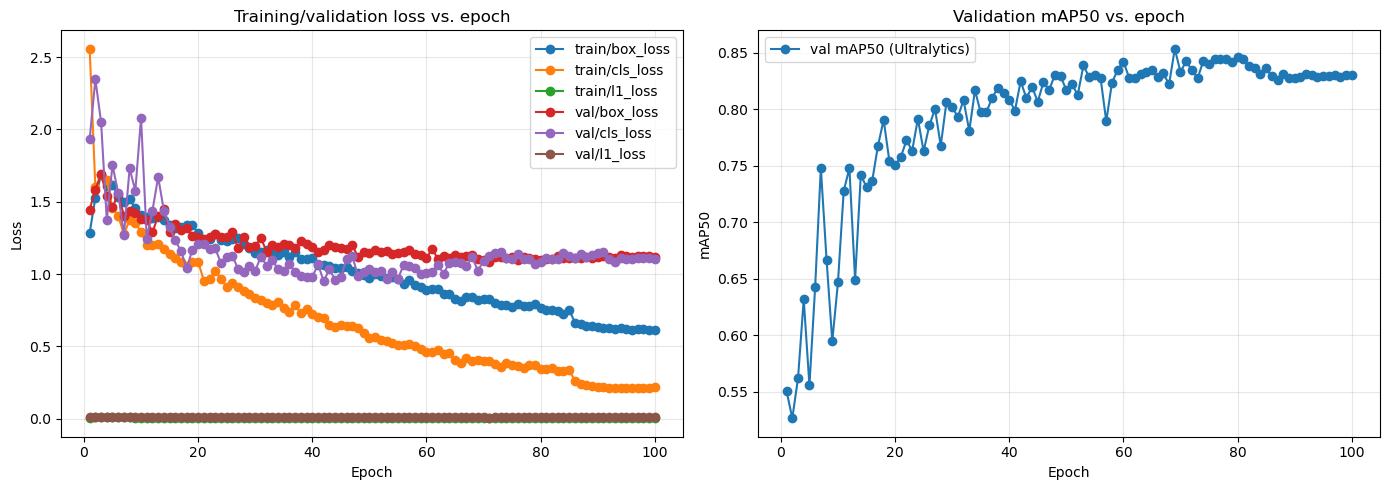

final_window epochs 81-100: Ultralytics val mAP50 0.8445 -> 0.8301 (max 0.8445, linear trend -0.0081)
mosaic_off   epochs 86-100: Ultralytics val mAP50 0.8291 -> 0.8301 (max 0.8313, linear trend +0.0021)
  epoch80.pt    epoch  81: organizer mAP@50 0.8114   recall at >= 95% precision: 0.5270
  epoch85.pt    epoch  86: organizer mAP@50 0.7991   recall at >= 95% precision: 0.5121
  epoch90.pt    epoch  91: organizer mAP@50 0.8004   recall at >= 95% precision: 0.4488
  epoch95.pt    epoch  96: organizer mAP@50 0.8057   recall at >= 95% precision: 0.4972
  last.pt       epoch 100: organizer mAP@50 0.8095   recall at >= 95% precision: 0.5084
Plateaued: no gain >= 0.005 over the final epochs.


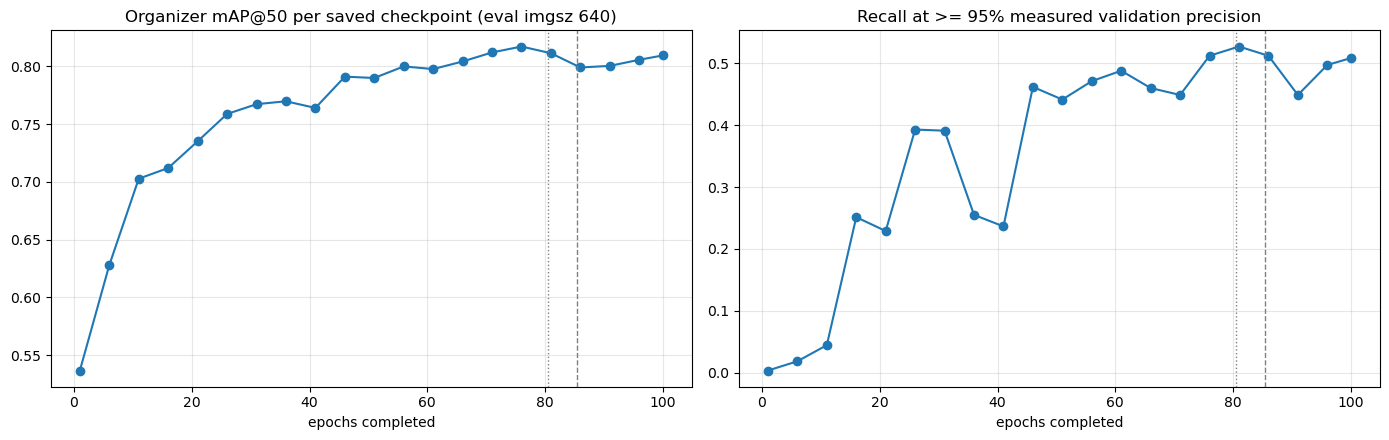

In [16]:
# Plot training loss vs epochs (from the history Ultralytics recorded in results.csv)
if not history and RUN_MODE == "evaluate":
    history = read_history(Path(EVAL_CHECKPOINT).resolve().parent.parent)

if history:
    epochs_x = [h["epoch"] for h in history]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for key in [k for k in history[0] if k.endswith("loss")]:
        ax.plot(epochs_x, [h[key] for h in history], marker="o", label=key)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Training/validation loss vs. epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # mAP@50 for validation vs Epoch (Ultralytics' own metric; the organizers' 11-point metric is in 3.2 / 4.2)
    ax2.plot(epochs_x, [h.get("metrics/mAP50(B)", float("nan")) for h in history], marker="o", label="val mAP50 (Ultralytics)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("mAP50")
    ax2.set_title(f"Validation mAP50 vs. epoch")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history available (evaluate mode without the checkpoint's results.csv).")

# --- Final 20 epochs: is the run still improving at epoch 100? ---
FINAL_EPOCHS = EVAL.get("final_epochs")
if FINAL_EPOCHS and FINAL_EPOCHS.get("available"):
    for _name in ("final_window", "mosaic_off"):
        _seg = FINAL_EPOCHS[_name]
        if _seg["epochs"]:
            print(f"{_name:<12} epochs {_seg['epochs'][0]}-{_seg['epochs'][1]}: Ultralytics val mAP50 "
                  f"{_seg['ultralytics_map50_first']:.4f} -> {_seg['ultralytics_map50_last']:.4f} "
                  f"(max {_seg['ultralytics_map50_max']:.4f}, linear trend {_seg['trend_gain']:+.4f})")
    for _x in FINAL_EPOCHS["organizer_final_window"]:
        _rec = "n/a" if _x["op_recall"] is None else f"{_x['op_recall']:.4f}"
        print(f"  {_x['ckpt']:<13} epoch {_x['epoch']:>3}: organizer mAP@50 {_x['map50_full']:.4f}"
              f"   recall at >= 95% precision: {_rec}")
    if FINAL_EPOCHS["still_improving"]:
        print("STILL IMPROVING at the end of training:", "; ".join(FINAL_EPOCHS["reasons"]))
        print("-> propose a longer run, compared only with baselines at the same longer budget; do not assume "
              f"{FINAL_EPOCHS['epochs']} epochs is enough.")
    else:
        print(f"Plateaued: no gain >= {FINAL_EPOCHS['min_gain']} over the final epochs.")
    (EVAL_DIR / "final_epochs.json").write_text(json.dumps(FINAL_EPOCHS, indent=2, default=str), encoding="utf-8")
else:
    print("No training history: final-epoch trend not available (evaluate mode on a checkpoint without results.csv).")

# Official mAP@50 and 95%-precision recall of every saved checkpoint
_pts = sorted((r for r in EVAL["results"] if r["epoch"] is not None and r["ckpt"] != "best.pt"), key=lambda r: r["epoch"])
if len(_pts) > 1:
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    ax.plot([r["epoch"] for r in _pts], [r["map50_full"] for r in _pts], marker="o")
    ax.set_title(f"Organizer mAP@50 per saved checkpoint (eval imgsz {EVAL_IMGSZ})")
    ax2.plot([r["epoch"] for r in _pts], [r["op_recall"] if r["op_found"] else float("nan") for r in _pts], marker="o")
    ax2.set_title("Recall at >= 95% measured validation precision")
    for _ax in (ax, ax2):
        _ax.axvline(EPOCHS - 20 + 0.5, color="gray", ls=":", lw=1)
        _ax.axvline(EPOCHS - CFG["close_mosaic"] + 0.5, color="gray", ls="--", lw=1)
        _ax.set_xlabel("epochs completed")
        _ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "checkpoints_by_epoch.png", dpi=110)
    plt.show()

### 4.2 Performance Analysis (Where is the model underperforming)

matching self-check (synthetic cases):
  ok - duplicate detections -> 1 TP + 1 FP
  ok - one prediction over two bags -> matches one; next prediction takes the unused bag
  ok - image without ground truth -> all FP
  ok - no predictions -> all FN, nothing selectable
  ok - tied scores -> one row, kept together (scores >= threshold)
  ok - selection: >= 95% measured precision, max recall, tie-breaks
  ok - one-pass table == re-matching at every threshold (random cases with ties)

checkpoint    epoch  mAP@50 starter |  conf >=  kept   TP   FP   FN precision  recall
epoch0.pt         1  0.5367  0.5372 |   0.8101     2    2    0  535    1.0000  0.0037
epoch5.pt         6  0.6280  0.6274 |   0.8120    10   10    0  527    1.0000  0.0186
epoch10.pt       11  0.7028  0.7054 |   0.7644    25   24    1  513    0.9600  0.0447
epoch15.pt       16  0.7120  0.7173 |   0.6910   142  135    7  402    0.9507  0.2514
epoch20.pt       21  0.7351  0.7382 |   0.7218   129  123    6  414    0.9535  0.2291


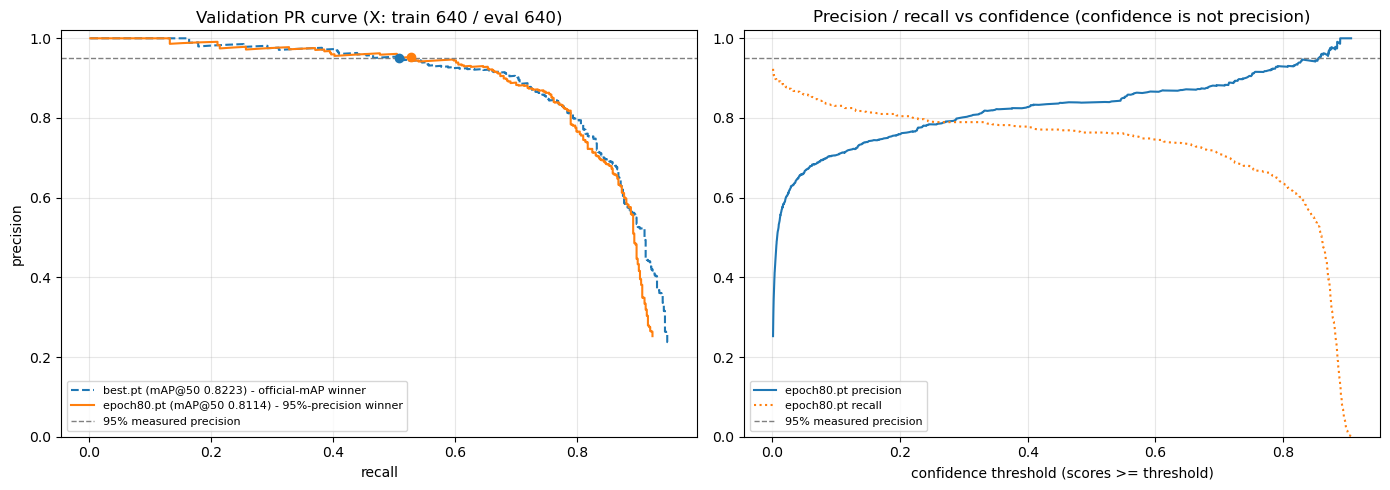


errors by suggested category (every error at the threshold): {
 "X_640": {
  "false_positive": {
   "model error": 13,
   "suspected missing annotation": 0,
   "questionable ground-truth box": 1,
   "ambiguous object": 0
  },
  "missed_bag": {
   "model error": 252,
   "suspected missing annotation": 0,
   "questionable ground-truth box": 2,
   "ambiguous object": 0
  }
 }
}
46 example images saved under /home/sagemaker-user/uprm-hackathon-2026/runs/annotation_audit/full_cmpX_yolo26x_train640_eval640_b4_ep100_20260926_214457 (suggestions only - review them by eye)


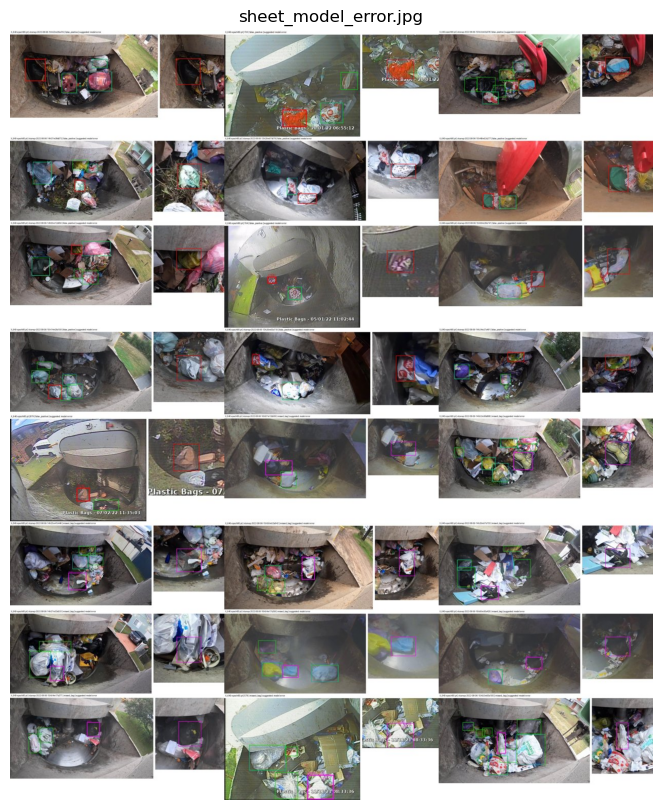

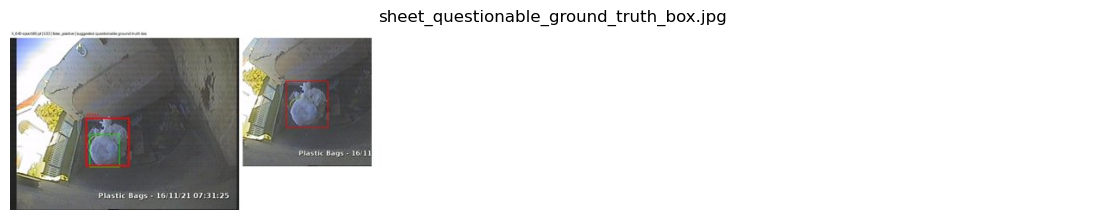

In [17]:
# --- 4.2 Where is the model underperforming? ---
# (a) Highest recall at >= 95% MEASURED validation precision (per checkpoint, from the predictions scored in 3.2)
# (b) Precision-recall plots
# (c) High-confidence false positives and representative missed bags, saved for organizer review
# The 95% is precision measured on this repeatedly used validation set - not a guarantee on unseen data - and the
# chosen confidence threshold is never used for the competition score (evaluate_map50 keeps conf=0.001).
"""Annotation audit: high-confidence false positives and representative missed bags, saved for organizer review.

Works on cached validation predictions (checkpoint_eval preds/*.pt), so no GPU is needed. Official labels are only
READ; nothing under data/ is ever written, and the official test set is never touched.

Every example gets a SUGGESTED category from simple geometric evidence; a person must confirm it by looking at the
image (the `reviewed_category` column is left empty for that):
  - model error                     : the labels look right and the model is wrong (duplicates, poor localization,
                                      bags it did not find)
  - suspected missing annotation    : a confident detection with no labelled bag anywhere near it, predicted by BOTH
                                      independently trained models
  - questionable ground-truth box   : prediction and label cover the same object but disagree on its extent (one box
                                      nests inside the other), or the label box itself is implausible
  - ambiguous object                : tiny or border-truncated bags that a person could reasonably label either way
"""

import csv
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence

import torch
from PIL import Image, ImageDraw
from torchvision.ops import boxes as box_ops


CATEGORIES = ("model error", "suspected missing annotation", "questionable ground-truth box", "ambiguous object")
NO_OVERLAP_IOU = 0.1       # an FP with less overlap than this with every labelled bag is "nowhere near" a bag
NEST_FRACTION = 0.85       # box A "nests" in box B when >= 85% of A's area lies inside B
TINY_SIDE_PX = 20          # sqrt(area) below this -> ambiguous
BORDER_PX = 2              # a box within 2 px of the image edge is truncated
LARGE_GT_FRACTION = 0.6    # a single "bag" covering >= 60% of the image is implausible
EXTREME_ASPECT = 5.0
AUDIT_FIELDS = ("run", "checkpoint", "threshold", "kind", "image", "index", "score", "x1", "y1", "x2", "y2",
                "best_iou_gt", "best_iou_pred", "best_pred_score", "found_at_any_conf", "other_run_agrees",
                "size_px", "suggested_category", "basis", "reviewed_category", "notes", "example_image")


@dataclass
class Match:
    order: List[int]        # prediction indices in descending confidence (kept predictions only)
    pred_gt: List[int]      # per kept prediction (same order): matched GT index or -1
    gt_matched: List[bool]  # per GT


def match_details(boxes: torch.Tensor, scores: torch.Tensor, gt: torch.Tensor, iou_match: float = IOU_MATCH) -> Match:
    """Organizer matching (same rule as operating_point.match_image), keeping which GT each prediction took."""
    order = torch.argsort(scores, descending=True, stable=True).tolist()
    used = torch.zeros(gt.shape[0], dtype=torch.bool)
    pred_gt = []
    if len(order) and gt.shape[0]:
        iou = box_ops.box_iou(boxes, gt)
        for pi in order:
            ious = iou[pi].clone()
            ious[used] = -1.0
            best_iou, best_gt = ious.max(dim=0)
            if best_iou.item() >= iou_match:
                used[best_gt] = True
                pred_gt.append(int(best_gt))
            else:
                pred_gt.append(-1)
    else:
        pred_gt = [-1] * len(order)
    return Match(order, pred_gt, used.tolist())


def _area(b) -> float:
    return max(0.0, float(b[2] - b[0])) * max(0.0, float(b[3] - b[1]))


def _inside_fraction(a, b) -> float:
    """Fraction of box a's area that lies inside box b."""
    ix = max(0.0, min(float(a[2]), float(b[2])) - max(float(a[0]), float(b[0])))
    iy = max(0.0, min(float(a[3]), float(b[3])) - max(float(a[1]), float(b[1])))
    return ix * iy / max(_area(a), 1e-9)


def nested(a, b) -> bool:
    return _inside_fraction(a, b) >= NEST_FRACTION or _inside_fraction(b, a) >= NEST_FRACTION


def touches_border(b, w: int, h: int) -> bool:
    return b[0] <= BORDER_PX or b[1] <= BORDER_PX or b[2] >= w - BORDER_PX or b[3] >= h - BORDER_PX


def _max_iou(box: torch.Tensor, others: torch.Tensor):
    if others.numel() == 0:
        return 0.0, -1
    iou = box_ops.box_iou(box.reshape(1, 4), others.reshape(-1, 4))[0]
    v, i = iou.max(dim=0)
    return float(v), int(i)


def suggest_fp(box, best_iou_gt: float, best_gt_box, duplicate: bool, other_agrees: Optional[bool]):
    if duplicate:
        return "model error", "duplicate: overlaps a bag already matched by a more confident prediction"
    if best_iou_gt < NO_OVERLAP_IOU:
        if other_agrees:
            return ("suspected missing annotation",
                    "no labelled bag nearby, and the other independently trained model also detects it")
        why = "no labelled bag nearby; " + ("the other model does not detect it" if other_agrees is False
                                            else "no second model to cross-check")
        return "model error", why + " (upgrade to 'suspected missing annotation' if a bag is visible)"
    if best_gt_box is not None and nested(box, best_gt_box):
        return ("questionable ground-truth box",
                f"covers a labelled bag (IoU {best_iou_gt:.2f}) but one box nests inside the other: extent disagreement")
    return "model error", f"poor localization (best IoU with a labelled bag {best_iou_gt:.2f} < {IOU_MATCH})"


def suggest_fn(gt_box, w: int, h: int, best_iou_pred: float, best_pred_box, found_at_any_conf: bool):
    side = _area(gt_box) ** 0.5
    if side < TINY_SIDE_PX:
        return "ambiguous object", f"tiny bag ({side:.0f} px)"
    if touches_border(gt_box, w, h) and _area(gt_box) < 0.01 * w * h:
        return "ambiguous object", "small bag truncated at the image border"
    bw, bh = float(gt_box[2] - gt_box[0]), float(gt_box[3] - gt_box[1])
    if _area(gt_box) >= LARGE_GT_FRACTION * w * h or max(bw / max(bh, 1e-9), bh / max(bw, 1e-9)) >= EXTREME_ASPECT:
        return "questionable ground-truth box", "label box covers most of the image or has an extreme aspect ratio"
    if best_pred_box is not None and 0.3 <= best_iou_pred < IOU_MATCH and nested(gt_box, best_pred_box):
        return ("questionable ground-truth box",
                f"a confident prediction covers it with IoU {best_iou_pred:.2f}, one box nested in the other")
    if not found_at_any_conf:
        return "model error", "never detected at IoU >= 0.5, even at conf 0.001"
    return "model error", "detected only below the operating threshold"


def _other_agrees(box, other_img: Optional[Dict], other_thr: Optional[float]) -> Optional[bool]:
    if other_img is None or other_thr is None:
        return None
    keep = other_img["scores"] >= other_thr
    v, _ = _max_iou(box, other_img["boxes"][keep])
    return v >= IOU_MATCH


def collect_errors(cache: Sequence[Dict], threshold: float, image_sizes: Dict[str, tuple], run: str, checkpoint: str,
                   other_cache: Optional[Sequence[Dict]] = None, other_threshold: Optional[float] = None) -> List[Dict]:
    """Every FP and FN of one checkpoint at `threshold`, with the evidence used for the suggested category."""
    other = {c["image"]: c for c in other_cache} if other_cache is not None else {}
    rows = []
    for img in cache:
        stem, gt = img["image"], img["gt"]
        w, h = image_sizes[stem]
        keep = img["scores"] >= threshold
        boxes, scores = img["boxes"][keep], img["scores"][keep]
        m = match_details(boxes, scores, gt)
        o = other.get(stem)
        for rank, (pi, g) in enumerate(zip(m.order, m.pred_gt)):
            if g >= 0:
                continue
            box = boxes[pi]
            best_iou, bi = _max_iou(box, gt)
            # duplicate: its best bag was matched (IoU >= 0.5) by a more confident prediction
            dup = bi >= 0 and best_iou >= IOU_MATCH and m.gt_matched[bi]
            agrees = _other_agrees(box, o, other_threshold) if other_cache is not None else None
            cat, basis = suggest_fp(box.tolist(), best_iou, gt[bi].tolist() if bi >= 0 else None, dup, agrees)
            rows.append({"run": run, "checkpoint": checkpoint, "threshold": threshold, "kind": "false_positive",
                         "image": stem, "index": pi, "score": float(scores[pi]), **_xyxy(box),
                         "best_iou_gt": best_iou, "best_iou_pred": None, "best_pred_score": None,
                         "found_at_any_conf": None, "other_run_agrees": agrees, "size_px": _area(box) ** 0.5,
                         "suggested_category": cat, "basis": basis})
        for gi in range(gt.shape[0]):
            if m.gt_matched[gi]:
                continue
            gbox = gt[gi]
            best_iou, bi = _max_iou(gbox, boxes)
            # found at any confidence >= 0.001: the most confident prediction overlapping it at IoU >= 0.5
            all_iou = box_ops.box_iou(gbox.reshape(1, 4), img["boxes"])[0] if img["boxes"].numel() else torch.zeros(0)
            hit = all_iou >= IOU_MATCH
            best_hit_score = float(img["scores"][hit].max()) if bool(hit.any()) else None
            other_found = _other_agrees(gbox, o, other_threshold) if other_cache is not None else None
            cat, basis = suggest_fn(gbox.tolist(), w, h, best_iou, boxes[bi].tolist() if bi >= 0 else None,
                                    best_hit_score is not None)
            if other_found is not None:
                basis += "; the other model " + ("finds it" if other_found else "also misses it")
            rows.append({"run": run, "checkpoint": checkpoint, "threshold": threshold, "kind": "missed_bag",
                         "image": stem, "index": gi, "score": None, **_xyxy(gbox), "best_iou_gt": None,
                         "best_iou_pred": best_iou, "best_pred_score": best_hit_score,
                         "found_at_any_conf": best_hit_score is not None, "other_run_agrees": other_found,
                         "size_px": _area(gbox) ** 0.5, "suggested_category": cat, "basis": basis})
    return rows


def _xyxy(b) -> Dict:
    x1, y1, x2, y2 = [round(float(v), 1) for v in b.tolist()]
    return {"x1": x1, "y1": y1, "x2": x2, "y2": y2}


def select_examples(rows: Sequence[Dict], top_fp: int = 30, per_size_missed: int = 8, hard_missed: int = 16) -> List[Dict]:
    """High-confidence FPs (most confident first) and representative missed bags.

    Missed bags: up to `hard_missed` never found at any confidence (largest first), plus up to `per_size_missed` per
    size bucket (small < 32 px, medium 32-96, large > 96) of the rest, spread evenly over how confidently they were
    eventually found. Deterministic.
    """
    fps = sorted((r for r in rows if r["kind"] == "false_positive"), key=lambda r: -r["score"])[:top_fp]
    missed = [r for r in rows if r["kind"] == "missed_bag"]
    hard = sorted((r for r in missed if not r["found_at_any_conf"]), key=lambda r: -r["size_px"])[:hard_missed]
    rest = [r for r in missed if r["found_at_any_conf"]]
    picked = []
    for lo, hi in ((0, 32), (32, 96), (96, float("inf"))):
        bucket = sorted((r for r in rest if lo <= r["size_px"] < hi), key=lambda r: -r["best_pred_score"])
        if len(bucket) <= per_size_missed:
            picked += bucket
        else:
            step = (len(bucket) - 1) / (per_size_missed - 1) if per_size_missed > 1 else 0
            picked += [bucket[round(i * step)] for i in range(per_size_missed)]
    return fps + hard + picked


def draw_example(img_path: Path, row: Dict, img_cache: Dict, threshold: float, out: Path) -> Path:
    """Left: the full image (labels green, kept predictions blue, the example red/magenta). Right: enlarged crop."""
    im = Image.open(img_path).convert("RGB")
    clean = im.copy()  # the enlarged crop is taken from the unannotated image so small objects stay visible
    d = ImageDraw.Draw(im)
    lw = max(2, round(max(im.size) / 400))
    for b in img_cache["gt"].tolist():
        d.rectangle(b, outline=(0, 220, 0), width=lw)
    keep = img_cache["scores"] >= threshold
    for b in img_cache["boxes"][keep].tolist():
        d.rectangle(b, outline=(30, 144, 255), width=max(1, lw - 1))
    box = [row["x1"], row["y1"], row["x2"], row["y2"]]
    color = (255, 0, 0) if row["kind"] == "false_positive" else (255, 0, 255)
    d.rectangle(box, outline=color, width=lw + 2)
    label = f"FP {row['score']:.2f}" if row["kind"] == "false_positive" else "MISSED"
    d.text((box[0] + 3, max(0, box[1] - 14)), label, fill=color)
    bw, bh = box[2] - box[0], box[3] - box[1]
    pad = max(bw, bh, 40)
    x0, y0 = max(0, box[0] - pad), max(0, box[1] - pad)
    crop = clean.crop((x0, y0, min(im.width, box[2] + pad), min(im.height, box[3] + pad)))
    scale = 360 / max(crop.size)
    crop = crop.resize((max(1, round(crop.width * scale)), max(1, round(crop.height * scale))))
    cb = [(box[0] - x0) * scale - 3, (box[1] - y0) * scale - 3, (box[2] - x0) * scale + 3, (box[3] - y0) * scale + 3]
    ImageDraw.Draw(crop).rectangle(cb, outline=color, width=2)  # drawn just outside the box
    full = im.copy()
    full.thumbnail((720, 720))
    canvas = Image.new("RGB", (full.width + crop.width + 10, max(full.height, crop.height) + 22), "white")
    canvas.paste(full, (0, 22))
    canvas.paste(crop, (full.width + 10, 22))
    ImageDraw.Draw(canvas).text((4, 4), f"{row['run']} {row['checkpoint']} | {row['image']} | {row['kind']} | "
                                        f"suggested: {row['suggested_category']}", fill=(0, 0, 0))
    out.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(out, quality=90)
    return out


def contact_sheet(paths: Sequence[Path], out: Path, cols: int = 3, width: int = 420) -> Optional[Path]:
    if not paths:
        return None
    thumbs = []
    for p in paths:
        with Image.open(p) as im:
            im = im.convert("RGB")
            thumbs.append(im.resize((width, max(1, round(im.height * width / im.width)))))
    rows = [thumbs[i:i + cols] for i in range(0, len(thumbs), cols)]
    heights = [max(t.height for t in r) for r in rows]
    sheet = Image.new("RGB", (cols * width, sum(heights)), "white")
    y = 0
    for r, hgt in zip(rows, heights):
        for j, t in enumerate(r):
            sheet.paste(t, (j * width, y))
        y += hgt
    out.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(out, quality=85)
    return out


def _slug(s: str) -> str:
    return s.replace(" ", "_").replace("-", "_")


def image_sizes(image_dir: Path, stems: Sequence[str]) -> Dict[str, tuple]:
    out = {}
    for s in stems:
        with Image.open(Path(image_dir) / f"{s}.jpg") as im:
            out[s] = im.size
    return out


def run_audit(runs: Sequence[Dict], image_dir: Path, out_dir: Path, top_fp: int = 30, per_size_missed: int = 8,
              hard_missed: int = 16) -> Dict:
    """runs: [{"run", "checkpoint", "cache", "threshold"}, ...] (1 or 2). With two runs each is cross-checked
    against the other. Writes audit_all_errors.csv, audit_examples.csv, examples/<category>/, contact sheets, README.md.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=False)  # never overwrite an earlier audit
    stems = [c["image"] for c in runs[0]["cache"]]
    sizes = image_sizes(image_dir, stems)
    all_rows, examples = [], []
    for i, r in enumerate(runs):
        other = runs[1 - i] if len(runs) == 2 else None
        rows = collect_errors(r["cache"], r["threshold"], sizes, r["run"], r["checkpoint"],
                              other["cache"] if other else None, other["threshold"] if other else None)
        all_rows += rows
        by_image = {c["image"]: c for c in r["cache"]}
        for k, row in enumerate(select_examples(rows, top_fp, per_size_missed, hard_missed)):
            name = f"{_slug(row['run'])}_{'fp' if row['kind'] == 'false_positive' else 'fn'}_{k:03d}_{row['image']}.jpg"
            path = out_dir / "examples" / _slug(row["suggested_category"]) / name
            draw_example(Path(image_dir) / f"{row['image']}.jpg", row, by_image[row["image"]], r["threshold"], path)
            examples.append({**row, "example_image": path.relative_to(out_dir).as_posix()})
    for name, rows in (("audit_all_errors.csv", all_rows), ("audit_examples.csv", examples)):
        with open(out_dir / name, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=AUDIT_FIELDS)
            w.writeheader()
            for row in rows:
                w.writerow({k: ("" if row.get(k) is None else row.get(k)) for k in AUDIT_FIELDS})
    counts = {r["run"]: {kind: {c: sum(1 for x in all_rows if x["run"] == r["run"] and x["kind"] == kind
                                       and x["suggested_category"] == c) for c in CATEGORIES}
                         for kind in ("false_positive", "missed_bag")} for r in runs}
    sheets = {}
    for cat in CATEGORIES:
        paths = [out_dir / e["example_image"] for e in examples if e["suggested_category"] == cat]
        s = contact_sheet(paths[:24], out_dir / f"sheet_{_slug(cat)}.jpg")
        if s is not None:
            sheets[cat] = s.name
    summary = {"runs": [{"run": r["run"], "checkpoint": r["checkpoint"], "threshold": r["threshold"]} for r in runs],
               "counts_all_errors": counts, "n_examples": len(examples), "contact_sheets": sheets,
               "labels_modified": False, "official_test_data_used": False}
    (out_dir / "audit_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    (out_dir / "README.md").write_text(_readme(runs, counts, examples), encoding="utf-8")
    return summary


def _readme(runs, counts, examples) -> str:
    lines = ["# Validation annotation audit (for organizer review)", "",
             "Examples of high-confidence false positives and missed bags on the **validation** split. "
             "No label file was modified and the official test set was not used.", "",
             "Colours: green = labelled bag, blue = model prediction kept at the threshold, red = the false positive "
             "in question (with its confidence), magenta = the missed labelled bag. Right panel = enlarged crop.", "",
             "`suggested_category` is produced by simple geometric rules (see `basis`); it is a starting point, "
             "**not a verdict**. Fill `reviewed_category` in `audit_examples.csv` after looking at each image.", "",
             "| run | checkpoint | threshold | kind | " + " | ".join(CATEGORIES) + " |",
             "|---|---|---|---|" + "---|" * len(CATEGORIES)]
    for r in runs:
        for kind in ("false_positive", "missed_bag"):
            c = counts[r["run"]][kind]
            lines.append(f"| {r['run']} | {r['checkpoint']} | {r['threshold']:.4f} | {kind} | "
                         + " | ".join(str(c[cat]) for cat in CATEGORIES) + " |")
    lines += ["", "Counts cover every error at the threshold; `examples/` holds the selected subset "
              f"({len(examples)} images): the most confident false positives, bags never detected at any confidence, "
              "and missed bags spread across sizes.", ""]
    return "\n".join(lines)

print("matching self-check (synthetic cases):")
for _case in self_check():
    print("  ok -", _case)


def _f(v, nd=4):
    return "n/a" if v is None else (f"{v:.{nd}f}" if isinstance(v, float) else str(v))


print(f"\n{'checkpoint':<13} {'epoch':>5} {'mAP@50':>7} {'starter':>7} | {'conf >=':>8} {'kept':>5} {'TP':>4} "
      f"{'FP':>4} {'FN':>4} {'precision':>9} {'recall':>7}")
for r in EVAL["results"]:
    tag = ("  <- official-mAP winner" if r["ckpt"] == EVAL["official_winner"] else "") + \
          ("  <- 95%-precision winner" if r["ckpt"] == EVAL["p95_winner"] else "")
    print(f"{r['ckpt']:<13} {str(r['epoch']):>5} {r['map50_full']:>7.4f} {r['map50_starter_loader']:>7.4f} | "
          f"{_f(r['op_threshold']):>8} {_f(r['op_n_pred']):>5} {_f(r['op_tp']):>4} {_f(r['op_fp']):>4} "
          f"{_f(r['op_fn']):>4} {_f(r['op_precision']):>9} {_f(r['op_recall']):>7}{tag}")

if P95 is None:
    print(f"\nNO checkpoint has any confidence threshold with measured validation precision >= {TARGET_PRECISION:.0%}.")
else:
    print(f"\nBest operating point: {P95['ckpt']} (epoch {P95['epoch']}) at confidence >= {P95['op_threshold']!r}")
    print(f"  measured precision {P95['op_precision']:.4f} = {P95['op_tp']} TP / {P95['op_n_pred']} retained predictions"
          f" | recall {P95['op_recall']:.4f} | TP {P95['op_tp']}  FP {P95['op_fp']}  FN (missed bags) {P95['op_fn']}")
    print(f"  confidence >= {P95['op_threshold']:.3f} is a score cut-off; {TARGET_PRECISION:.0%} is the precision MEASURED "
          f"at that cut-off on these {EVAL['n_images']} validation images (not a guarantee on unseen data).")

# (b) Precision-recall plots for the two winners
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for _role, _r, _style in (("official-mAP winner", OFFICIAL, "--"), ("95%-precision winner", P95, "-")):
    if _r is None or (_style == "--" and P95 is not None and _r["ckpt"] == P95["ckpt"]):
        continue
    _rows = operating_point_from_cache(load_cache(EVAL_DIR / "preds" / f"{Path(_r['ckpt']).stem}.pt"))["rows"]
    ax1.plot([x["recall"] for x in _rows], [x["precision"] for x in _rows], _style,
             label=f"{_r['ckpt']} (mAP@50 {_r['map50_full']:.4f}) - {_role}")
    if _r["op_found"]:
        ax1.scatter([_r["op_recall"]], [_r["op_precision"]], zorder=3)
    if _style == "-" or P95 is None:
        ax2.plot([x["threshold"] for x in _rows], [x["precision"] for x in _rows], label=f"{_r['ckpt']} precision")
        ax2.plot([x["threshold"] for x in _rows], [x["recall"] for x in _rows], ":", label=f"{_r['ckpt']} recall")
for _ax in (ax1, ax2):
    _ax.axhline(TARGET_PRECISION, color="gray", ls="--", lw=1, label=f"{TARGET_PRECISION:.0%} measured precision")
    _ax.set_ylim(0, 1.02)
    _ax.grid(True, alpha=0.3)
    _ax.legend(fontsize=8)
ax1.set_xlabel("recall")
ax1.set_ylabel("precision")
ax1.set_title(f"Validation PR curve ({EXPERIMENT}: train {TRAIN_IMGSZ} / eval {EVAL_IMGSZ})")
ax2.set_xlabel("confidence threshold (scores >= threshold)")
ax2.set_title("Precision / recall vs confidence (confidence is not precision)")
plt.tight_layout()
plt.savefig(EVAL_DIR / "pr_curves.png", dpi=110)
plt.show()

# (c) Error examples for this run. The cross-model check against earlier runs is added by rcd_yolo.compare_models.
_ck = P95 or OFFICIAL
AUDIT_DIR = REPO_ROOT / "runs" / "annotation_audit" / RUN_NAME
AUDIT = run_audit([{"run": f"{EXPERIMENT}_{TRAIN_IMGSZ}", "checkpoint": _ck["ckpt"],
                    "cache": load_cache(EVAL_DIR / "preds" / f"{Path(_ck['ckpt']).stem}.pt"),
                    "threshold": _ck["op_threshold"] if _ck["op_found"] else 0.5}], val_ds.image_dir, AUDIT_DIR)
print("\nerrors by suggested category (every error at the threshold):", json.dumps(AUDIT["counts_all_errors"], indent=1))
print(f"{AUDIT['n_examples']} example images saved under {AUDIT_DIR} (suggestions only - review them by eye)")
for _sheet in list(AUDIT["contact_sheets"].values())[:2]:
    plt.figure(figsize=(14, 10))
    plt.imshow(Image.open(AUDIT_DIR / _sheet))
    plt.axis("off")
    plt.title(_sheet)
    plt.show()

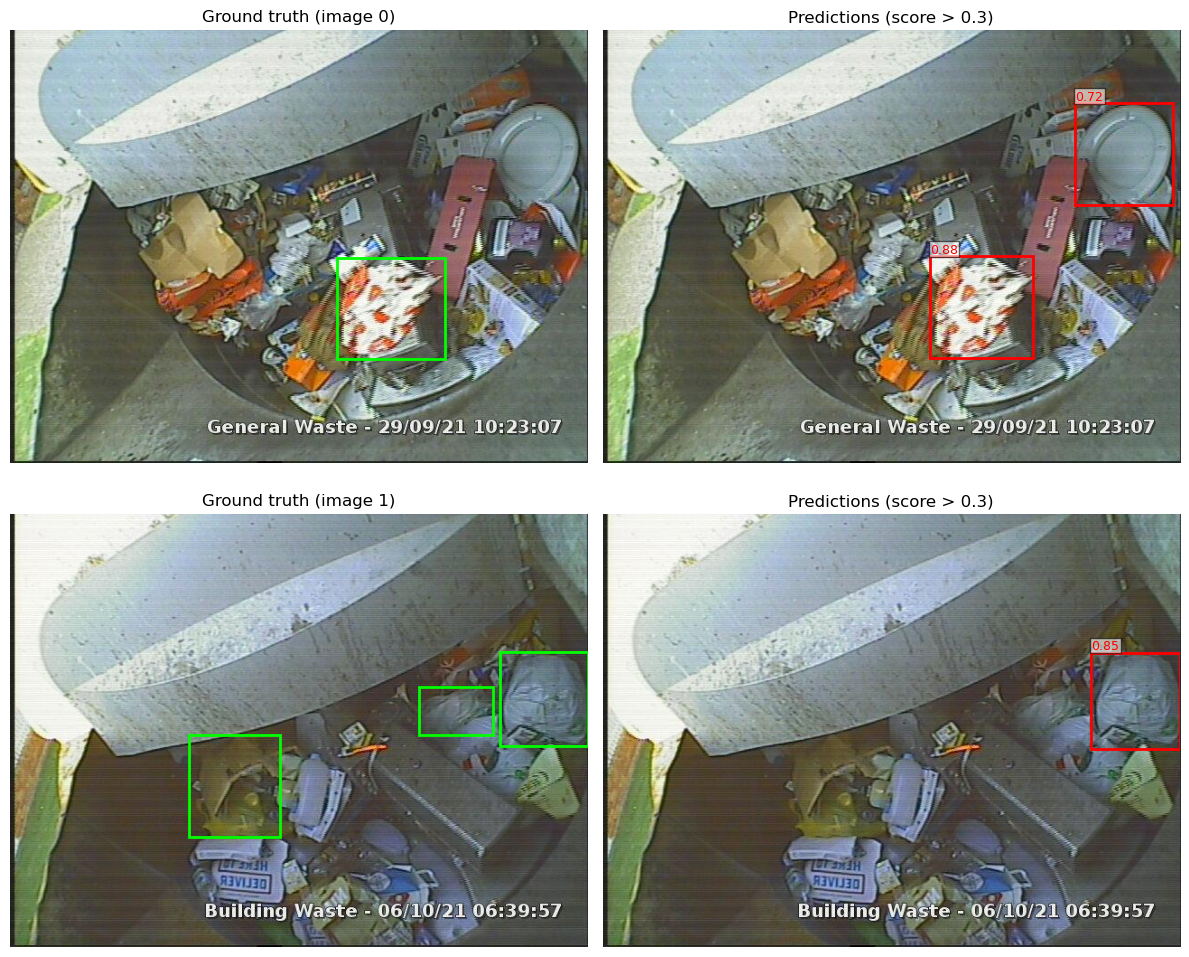

In [18]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_images: int = 4, score_thresh: float = 0.3):
    model.eval()
    idxs = list(range(min(num_images, len(dataset))))
    fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 5 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(idxs):
        img, target = dataset[idx]
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img_np)
        ax_gt.set_title(f"Ground truth (image {idx})")
        ax_gt.axis("off")
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax_gt.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            ))

        # Predictions
        preds = model([img.to(device)])[0]
        ax_pr = axes[row, 1]
        ax_pr.imshow(img_np)
        ax_pr.set_title(f"Predictions (score > {score_thresh})")
        ax_pr.axis("off")
        for box, score in zip(preds["boxes"].cpu(), preds["scores"].cpu()):
            if float(score) < score_thresh:
                continue
            x1, y1, x2, y2 = box.tolist()
            ax_pr.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="red", linewidth=2,
            ))
            ax_pr.text(x1, max(0, y1 - 4), f"{float(score):.2f}",
                       color="red", fontsize=9,
                       bbox=dict(facecolor="white", alpha=0.6, pad=1))

    plt.tight_layout()
    plt.show()


# Visualization hides boxes below 0.3 confidence; scoring above still uses conf=0.001
visualize_predictions(model, val_ds, DEVICE, num_images=2, score_thresh=0.3)

## 5. Test

Speak to a Hackathon Organizer when your team is ready to submit a final model. You will receive two keys to be entered below to download the test dataset and score your model.

In this notebook, set `RUN_OFFICIAL_TEST = True` in 5.1 only once the model and settings are frozen. The two keys are then asked for at runtime (password prompts), so they are never stored in the notebook. With the default `False`, Run All never prompts, downloads, or scores the official test set.

### 5.1 Download Test Data

In [19]:
# Official test access (organizer keys are typed at runtime prompts in the next cell, never stored here)
RUN_OFFICIAL_TEST = False

BUCKET = "uprm-hackathon-data"
PREFIX = "2026/test/"            # trailing slash is optional but recommended
DESTINATION = f"{REPO_ROOT}/data/test/"        # local root folder where files will be saved
REGION = "us-east-1"

In [20]:
import os
from pathlib import Path

if RUN_OFFICIAL_TEST:
    from getpass import getpass

    import boto3

    # Download
    s3 = boto3.resource('s3',
                        aws_access_key_id=getpass("AWS_ACCESS_KEY_ID: "),
                        aws_secret_access_key=getpass("AWS_SECRET_ACCESS_KEY: "),
                        region_name=REGION)

    bucket = s3.Bucket(BUCKET)

    for obj in bucket.objects.filter(Prefix=PREFIX):
        if obj.key.endswith('/'):  # skip "folder" placeholders
            continue
        rel_path = os.path.relpath(obj.key, PREFIX)
        local_path = Path(DESTINATION) / rel_path
        local_path.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {obj.key} -> {local_path}')
        bucket.download_file(obj.key, str(local_path))
    del s3, bucket
else:
    print("RUN_OFFICIAL_TEST is False - official test data not downloaded.")

RUN_OFFICIAL_TEST is False - official test data not downloaded.


### 5.2 Create Test DataLoader

In [21]:
# Create DataLoader for Test Set
test_loader = None
if RUN_OFFICIAL_TEST:
    test_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="test")
    print(f"test samples: {len(test_ds)}")
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
        drop_last=False
    )
else:
    print("RUN_OFFICIAL_TEST is False - no test loader.")

RUN_OFFICIAL_TEST is False - no test loader.


### 5.3 Grade Model on Test Set

In [22]:
if RUN_OFFICIAL_TEST and test_loader is not None:
    map50 = evaluate_map50(model, test_loader, DEVICE)
    print(f"Test mAP@50 (plastic_bag): {map50:.4f}")
    print(f"Test mAP@50 (plastic_bag), all digits: {map50!r}")
else:
    print("RUN_OFFICIAL_TEST is False - official test set not scored.")

RUN_OFFICIAL_TEST is False - official test set not scored.


# 6. Grading/Submission Guidelines

## Submissions
Please email your submissions to hamzah.abdulrazzaq@lmco.com. All these items must be complete in order for your submission to be considered for evaluation. 
> 1. Email title set to *yourteamname_submission* 
> 2. The python notebook with all your code (.ipynb) 
> 3. Your model checkpoint (.pt) file
> 4. mAP@50 test score copied in with all the digits

**NOTE**: If your email submission is blocked, please try resending the email with a .allow extension added to the file or email title.

## Evaluation Process
> - The submission deadline is on Sunday (9/27) 12PM.
> - Presentations will take place on Sunday (9/27) 2PM for the top 3 teams highest performing solutions. Teams will provide a walkthrough of their code. A winner shall be announced thereafter.